In [4]:
import pandas as pd
import os

# 输入和输出路径
input_directory = r'G:\\深圳市人与出租车数据\\GPS与OD数据'
output_directory = r'E:\\Electric Ride-Hailing Vehicle'
output_file = os.path.join(output_directory, 'GPS_data.csv')

# 文件名列表
file_names = [
    '4403_2019_09_23.csv',
    '4403_2019_09_24.csv',
    '4403_2019_09_25.csv',
    '4403_2019_09_26.csv',
    '4403_2019_09_27.csv',
    '4403_2019_09_28.csv',
    '4403_2019_09_29.csv'
]

# 确保输出目录存在
os.makedirs(output_directory, exist_ok=True)

# 载入所有CSV文件并将其合并
dataframes = []

for file_name in file_names:
    file_path = os.path.join(input_directory, file_name)
    
    # 读取CSV文件
    try:
        df = pd.read_csv(file_path)
        
        # 重命名列
        df = df.rename(columns={
            '经度': 'longitude',
            '纬度': 'latitude',
            '时间': 'timestamp'
        })
        
        dataframes.append(df)
    except FileNotFoundError:
        print(f"文件未找到: {file_path}")
    except Exception as e:
        print(f"读取文件时发生错误: {file_path}, {e}")

# 将所有数据帧合并成一个
merged_df = pd.concat(dataframes, ignore_index=True)

# 删除不需要的列
columns_to_keep = ['ID', 'longitude', 'latitude', 'timestamp']
try:
    merged_df = merged_df[columns_to_keep]
except KeyError:
    missing_cols = [col for col in columns_to_keep if col not in merged_df.columns]
    print(f"确保CSV文件中存在以下列: {missing_cols}")

# 确保时间戳是datetime格式
try:
    merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'])
except KeyError:
    print("确保CSV文件中存在 'timestamp' 列。")
except Exception as e:
    print(f"转换时间戳时出现错误: {e}")

# 按照ID和时间戳排序
try:
    sorted_df = merged_df.sort_values(by=['ID', 'timestamp'])
except KeyError:
    print("确保CSV文件中存在 'ID' 和 'timestamp' 列。")
except Exception as e:
    print(f"排序数据时出现错误: {e}")

# 保存合并且排序后的数据
try:
    sorted_df.to_csv(output_file, index=False)
    print(f"数据已成功合并和排序，保存到 {output_file}")
except Exception as e:
    print(f"保存文件时出现错误: {e}")

数据已成功合并和排序，保存到 E:\\Electric Ride-Hailing Vehicle\GPS_data.csv


In [2]:
print(f"{len(sorted_df)} records remain.")
print(sorted_df.columns)

30766783 records remain.
Index(['ID', 'longitude', 'latitude', 'timestamp'], dtype='object')


In [7]:
import pandas as pd

# 读取EV_GPS数据
ev_gps = pd.read_csv("E:\\Electric Ride-Hailing Vehicle\\GPS_data.csv")

# 深圳市的地理边界范围
shenzhen_lat_range = (22.45, 22.85)
shenzhen_lon_range = (113.75, 114.65)

# 过滤掉超出深圳市边界的数据
ev_gps_filtered = ev_gps[
    (ev_gps['latitude'].between(*shenzhen_lat_range)) &
    (ev_gps['longitude'].between(*shenzhen_lon_range))
].copy()

print(f"After boundary filtering: {len(ev_gps_filtered)} records remain.")

After boundary filtering: 30764228 records remain.


In [8]:
import numpy as np

# 定义计算经纬度距离的函数 (Haversine formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 地球半径，单位为公里
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c  # 返回距离，单位为公里

# 确保时间戳列为 datetime 类型
ev_gps_filtered['timestamp'] = pd.to_datetime(ev_gps_filtered['timestamp'])

# 按ID进行排序
ev_gps_filtered.sort_values(by=['ID', 'timestamp'], inplace=True)

# 计算相邻点之间的时间差和距离
ev_gps_filtered['time_diff'] = ev_gps_filtered.groupby('ID')['timestamp'].diff().dt.total_seconds() / 3600  # 小时
ev_gps_filtered['distance'] = ev_gps_filtered.groupby('ID').apply(
    lambda group: haversine(group['latitude'].shift(), group['longitude'].shift(), group['latitude'], group['longitude'])
).reset_index(drop=True)

# 计算速度 km/h
ev_gps_filtered['speed'] = ev_gps_filtered['distance'] / ev_gps_filtered['time_diff']

# 过滤掉速度超过120km/h的数据
ev_gps_cleaned = ev_gps_filtered[ev_gps_filtered['speed'] <= 120]

print(f"After speed filtering: {len(ev_gps_cleaned)} records remain.")

# 保存最终结果
ev_gps_cleaned.to_csv("EV_GPS_Cleaned.csv", index=False)

After speed filtering: 14740626 records remain.


In [9]:
import pandas as pd

# 读取CSV文件
file_path = 'EV_GPS_Cleaned.csv'  # 文件路径
df = pd.read_csv(file_path)

# 确保时间戳列是datetime类型
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 按ID分组并处理
processed_data = []

for vehicle_id, group in df.groupby('ID'):
    # 将时间戳调整为整分钟
    group['minute'] = group['timestamp'].dt.floor('min')
    # 保留每分钟的第一条数据
    first_per_minute = group.groupby('minute').first().reset_index()
    # 将时间戳调整为整分钟时间
    first_per_minute['timestamp'] = first_per_minute['minute']
    # 删除辅助列
    first_per_minute = first_per_minute.drop(columns=['minute'])
    # 添加到结果中
    processed_data.append(first_per_minute)

# 合并所有分组后的数据
result_df = pd.concat(processed_data, ignore_index=True)

# 保存结果到新文件
output_file_path = 'EV_GPS_Cleaned.csv'
result_df.to_csv(output_file_path, index=False)

# 输出最终数据行数
print(f"The processed dataset has {len(result_df)} rows.")

The processed dataset has 5519769 rows.


In [10]:
import pandas as pd

# 读取数据
df = pd.read_csv("EV_GPS_Cleaned.csv")

# 确保 timestamp 列为 datetime 类型，方便后续处理
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 定义添加缺失时间点的函数
def add_missing_timestamps_per_day(group):
    """
    对于每个 Vehicle ID 的每天数据，如果缺少 0:00:00 或 23:59:59，分别添加这些时间点的数据。
    """
    # 提取日期部分，确保数据按时间排序
    group['date'] = group['timestamp'].dt.date
    rows_to_add = []

    # 按天分组处理
    for date, day_data in group.groupby('date'):
        # 确保数据按时间排序
        day_data = day_data.sort_values(by='timestamp')

        # 定义当天的 0:00:00 和 23:59:59 时间点
        start_time = pd.Timestamp(f"{date} 00:00:00")
        end_time = pd.Timestamp(f"{date} 23:59:59")

        # 如果当天没有 0:00:00 数据点，添加一条数据
        if not any(day_data['timestamp'] == start_time):
            first_row = day_data.iloc[0].copy()
            first_row['timestamp'] = start_time
            rows_to_add.append(first_row)

        # 如果当天没有 23:59:59 数据点，添加一条数据
        if not any(day_data['timestamp'] == end_time):
            last_row = day_data.iloc[-1].copy()
            last_row['timestamp'] = end_time
            rows_to_add.append(last_row)

    # 合并新添加的行与原始数据
    if rows_to_add:
        group = pd.concat([group] + [pd.DataFrame(rows_to_add)], ignore_index=True)

    # 删除临时列并返回按时间排序后的数据
    group = group.drop(columns=['date'])
    return group.sort_values(by='timestamp')

# 对每个 Vehicle ID 分组，并为每天添加缺失的时间点
df_processed = df.groupby('ID', group_keys=False).apply(add_missing_timestamps_per_day)

# 保存处理后的数据为新的 CSV 文件
df_processed.to_csv("EV_GPS_Cleaned_Processed.csv", index=False)

# 输出数据的总条数
print(f"Processed data contains {len(df_processed)} records.")

Processed data contains 5654219 records.


In [9]:
import pandas as pd
from datetime import datetime, timedelta

# 读取CSV文件
df = pd.read_csv('EV_GPS_Cleaned_Processed.csv')

# 将timestamp列转换为datetime类型
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 创建需要检查的时间点列表
start_date = datetime(2019, 9, 23)
end_date = datetime(2019, 9, 29, 23, 59, 59)
check_times = []

# 生成每天的00:00:00和23:59:59
current_date = start_date
while current_date <= end_date:
    check_times.append(current_date)
    if current_date.date() != end_date.date():
        check_times.append(current_date.replace(hour=23, minute=59, second=59))
    current_date += timedelta(days=1)

# 获取所有唯一的ID
unique_ids = df['ID'].unique()

# 创建新行的列表
new_rows = []

# 对每个ID进行处理
for id_value in unique_ids:
    # 获取当前ID的所有数据
    id_data = df[df['ID'] == id_value].sort_values('timestamp')
    
    # 对每个需要检查的时间点进行处理
    for check_time in check_times:
        # 检查是否存在该时间点的数据
        if not any(id_data['timestamp'] == check_time):
            # 找到最接近且小于该时间点的行
            prev_row = id_data[id_data['timestamp'] < check_time].iloc[-1] if not id_data[id_data['timestamp'] < check_time].empty else None
            
            # 如果找到了前一行，创建新行
            if prev_row is not None:
                new_row = prev_row.copy()
                new_row['timestamp'] = check_time
                new_rows.append(new_row)

# 如果有新行要添加
if new_rows:
    # 将新行转换为DataFrame
    new_df = pd.DataFrame(new_rows)
    
    # 合并原始数据和新行
    df = pd.concat([df, new_df], ignore_index=True)
    
    # 按ID和timestamp排序
    df = df.sort_values(['ID', 'timestamp', 'longitude', 'latitude', 'time_diff', 'distance', 'speed'])

# 保存到CSV文件
df.to_csv('EV_GPS_Cleaned_Processed.csv', index=False)

print("处理完成！")

# 输出数据的总条数
print(f"Processed data contains {len(df)} records.")

处理完成！
Processed data contains 5730241 records.


In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 读取CSV数据
df = pd.read_csv('EV_GPS_Cleaned_Processed.csv')

# 创建点几何
df['geometry'] = df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)

# 转换为GeoDataFrame
gdf_points = gpd.GeoDataFrame(df, geometry='geometry')

# 读取交通小区的shapefile
gdf_areas = gpd.read_file(r'G:\\深圳土地数据\\交通小区\\交通小区.shp')

# 确保两个数据帧的CRS一致
gdf_points = gdf_points.set_crs(gdf_areas.crs, allow_override=True)

# 使用空间连接将点关联到相应区域
gdf_joined = gpd.sjoin(gdf_points, gdf_areas, predicate='within')

# 从结果中选择所需列，包括原始数据和新的area_ID
result = gdf_joined[['ID', 'timestamp', 'longitude', 'latitude', 'area_ID']]

# 保存结果到CSV
result.to_csv('EV_GPS_with_traffic_area_ID.csv', index=False)

print("Operation completed and the file is saved as 'EV_GPS_with_traffic_area_ID.csv'.")

print(f"Processed data contains {len(result)} records.")

Operation completed and the file is saved as 'EV_GPS_with_traffic_area_ID.csv'.
Processed data contains 5675832 records.


In [6]:
import pandas as pd

# 读取CSV文件
file_name = "EV_GPS_with_traffic_area_ID.csv"
df = pd.read_csv(file_name)

# 将timestamp列转换为datetime格式
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 定义时间范围
start_date = pd.to_datetime('2019-09-23')
end_date = pd.to_datetime('2019-09-29')

# 提取日期部分
df['date'] = df['timestamp'].dt.date

# 按照ID分组，计算每辆车在7天内有数据的天数
vehicle_data = df[(df['date'] >= start_date.date()) & (df['date'] <= end_date.date())]  # 筛选时间范围内的数据
vehicle_day_count = vehicle_data.groupby('ID')['date'].nunique()  # 每辆车的数据天数

# 找出有4天及以上数据的车辆
vehicle_count_4_days = (vehicle_day_count >= 4).sum()

# 找出有5天及以上数据的车辆
vehicle_count_5_days = (vehicle_day_count >= 5).sum()

# 计算总的汽车数量
total_vehicles = df['ID'].nunique()

# 输出结果
print(f"在2019-09-23到2019-09-29期间，四天及以上有数据的汽车数量为: {vehicle_count_4_days}")
print(f"在2019-09-23到2019-09-29期间，五天及以上有数据的汽车数量为: {vehicle_count_5_days}")
print(f"一共的汽车数量为: {total_vehicles}")

在2019-09-23到2019-09-29期间，四天及以上有数据的汽车数量为: 15268
在2019-09-23到2019-09-29期间，五天及以上有数据的汽车数量为: 13859
一共的汽车数量为: 20537


In [12]:
import pandas as pd
import os

# 读取CSV文件
df = pd.read_csv("EV_GPS_with_traffic_area_ID.csv")

# 输出文件路径和设置
output_directory = "E://Electric Ride-Hailing Vehicle//split_files"
os.makedirs(output_directory, exist_ok=True)  # 如果文件夹不存在则创建

# 每个文件的最大记录数
MAX_RECORDS = 300000

# 初始化变量
file_index = 1
current_index = 0  # 追踪当前处理的起始位置

# 遍历数据集并切分
while current_index < len(df):
    # 设置临时结束位置，暂定为 current_index + MAX_RECORDS
    tentative_end_index = current_index + MAX_RECORDS

    # 如果临时结束位置超出了数据总量，则将其限制在数据长度范围内
    if tentative_end_index >= len(df):
        tentative_end_index = len(df)

    # 检查最后一条记录的Vehicle ID
    last_vehicle_id = df.iloc[tentative_end_index - 1]["ID"]

    # 找出最后一个Vehicle ID的所有记录的起始位置
    while (
        tentative_end_index < len(df) and
        df.iloc[tentative_end_index]["ID"] == last_vehicle_id
    ):
        tentative_end_index += 1

    # 如果当前分片中的第一个Vehicle ID已经在上一文件部分保存，则从该ID的开始重新切
    split_df = df[current_index:tentative_end_index]
    
    # 如果该分片大于MAX_RECORDS，则需要将该Vehicle ID的部分移动到下一个文件
    if len(split_df) > MAX_RECORDS:
        # 找到超过MAX_RECORDS后的第一个不同的Vehicle ID的起始位置
        valid_end_index = current_index + MAX_RECORDS
        next_vehicle_id = df.iloc[valid_end_index]["ID"]

        while (
            valid_end_index > current_index and
            df.iloc[valid_end_index - 1]["ID"] == next_vehicle_id
        ):
            valid_end_index -= 1

        split_df = df[current_index:valid_end_index]
        tentative_end_index = valid_end_index

    # 保存切分后的文件
    output_file_path = os.path.join(output_directory, f"split_file_{file_index}.csv")
    split_df.to_csv(output_file_path, index=False)

    print(f"Saved {output_file_path} with {len(split_df)} records.")

    # 更新当前索引和文件编号
    current_index = tentative_end_index
    file_index += 1

print("All files have been split and saved successfully.")

Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_1.csv with 299211 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_2.csv with 299335 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_3.csv with 299653 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_4.csv with 299988 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_5.csv with 299255 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_6.csv with 299979 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_7.csv with 299968 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_8.csv with 299638 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_9.csv with 299498 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_10.csv with 299433 records.
Saved E://Electric Ride-Hailing Vehicle//split_files\split_file_11.csv with 298206 record

In [ ]:
import pandas as pd
import requests
import time

# 替换百度地图API密钥
BAIDU_API_KEY = 'hqWlBBFtwGd4iHMB1MwqGtguGwQLJVFC'

def get_navigation_distance(start_lat, start_lng, end_lat, end_lng):
    """调用百度批量算路API获取两点间的导航距离（单位：公里）"""
    url = f'http://api.map.baidu.com/routematrix/v2/driving'
    params = {
        'output': 'json',
        'ak': BAIDU_API_KEY,
        'origins': f'{start_lat},{start_lng}',
        'destinations': f'{end_lat},{end_lng}',
    }
    try:
        response = requests.get(url, params=params)
        data = response.json()
        if 'result' in data and len(data['result']) > 0:
            distance_meters = data['result'][0]['distance']['value']
            # 将米转换为公里
            return distance_meters / 1000.0
        else:
            print(f"Error in API call: {data}")
            return 0.0
    except Exception as e:
        print(f"Exception during API call: {e}")
        return 0.0

# 加载CSV数据
df = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\split_file_1.csv')

# 确保按照Vehicle ID和timestamp排序
df.sort_values(by=['ID', 'timestamp'], inplace=True)

# 添加一列用于存储导航距离，初始化为0
df['navigation_distance'] = 0.0

# 遍历每个Vehicle ID分组
for vehicle_id, group in df.groupby('ID'):
    # 获取该车辆的数据索引
    indices = group.index
    distances = []  # 临时存储当前 Vehicle ID 的距离列表

    # 遍历该分组数据的每一对相邻点
    for i in range(len(group)):
        if i == 0:  # 第一条记录的导航距离为0
            distances.append(0.0)
        else:
            # 获取相邻点的经纬度
            start_lat, start_lng = group.iloc[i-1]['latitude'], group.iloc[i-1]['longitude']
            end_lat, end_lng = group.iloc[i]['latitude'], group.iloc[i]['longitude']

            # 如果起点和终点相同，距离为0
            if start_lat == end_lat and start_lng == end_lng:
                distances.append(0.0)
            else:
                # 调用百度API获取导航距离
                distance_km = get_navigation_distance(start_lat, start_lng, end_lat, end_lng)
                distances.append(distance_km)

            # 防止API的QPS过高
            time.sleep(0.05)

    # 更新原始数据框中的距离列
    df.loc[indices, 'navigation_distance'] = distances

# 根据导航行驶里程计算耗电量
electricity_consumption_per_100km = 13.6
df['electricity_consumption_kWh'] = (df['navigation_distance'] * electricity_consumption_per_100km) / 100

# 保存结果到新的CSV文件
df.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\split_file_1_with_navigation.csv', index=False)

print("Operation completed and the file is saved as 'split_file_1_with_navigation.csv'.")

Operation completed and the file is saved as 'split_file_1_with_navigation.csv'.


In [1]:
import pandas as pd
import os

# 定义文件夹路径
folder_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\'

# 定义要合并的文件列表
file_names = [
    'split_file_1_with_navigation.csv',
    'split_file_2_with_navigation.csv',
    'split_file_3_with_navigation.csv',
    'split_file_4_with_navigation.csv',
    'split_file_5_with_navigation.csv',
    'split_file_6_with_navigation.csv',
    'split_file_7_with_navigation.csv',
    'split_file_8_with_navigation.csv',
    'split_file_9_with_navigation.csv',
    'split_file_10_with_navigation.csv',
    'split_file_11_with_navigation.csv',
    'split_file_12_with_navigation.csv',
    'split_file_13_with_navigation.csv',
    'split_file_14_with_navigation.csv',
    'split_file_15_with_navigation.csv',
    'split_file_16_with_navigation.csv',
    'split_file_17_with_navigation.csv',
    'split_file_18_with_navigation.csv',
    'split_file_19_with_navigation.csv'
]

# 初始化一个空列表，用于存储数据
data_frames = []

# 逐个读取文件并存储到列表中
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)  # 构建完整路径
    df = pd.read_csv(file_path)  # 读取文件
    data_frames.append(df)  # 添加到列表

# 合并所有文件
combined_df = pd.concat(data_frames, ignore_index=True)

# 确保 'ID' 和 'timestamp' 列存在
if 'ID' not in combined_df.columns or 'timestamp' not in combined_df.columns:
    raise ValueError("The combined file must contain 'ID' and 'timestamp' columns.")

# 转换 'timestamp' 列为日期时间格式（如果尚未是日期时间格式）
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# 按照 'ID' 和 'timestamp' 排序
combined_df = combined_df.sort_values(by=['ID', 'timestamp']).reset_index(drop=True)

# 保存合并后的文件
output_file = os.path.join(folder_path, 'merged_file_with_navigation.csv')
combined_df.to_csv(output_file, index=False)

print(f"Merged and sorted file saved to: {output_file}")

Merged and sorted file saved to: E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation.csv


In [2]:
import pandas as pd
import os

# 文件路径
file_path = r"E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation.csv"
output_path = r"E:\\Electric Ride-Hailing Vehicle\\split_files\\filtered_merged_file_with_navigation.csv"

# 检查文件是否存在
if not os.path.exists(file_path):
    print(f"文件路径无效或文件不存在: {file_path}")
else:
    # 读取数据
    data = pd.read_csv(file_path)
    
    # 原始数据统计
    original_data_count = len(data)  # 原数据条数
    original_id_count = data['ID'].nunique()  # 原ID数量
    
    # 提取日期部分
    data['date'] = pd.to_datetime(data['timestamp']).dt.date
    
    # 统计每个ID的天数
    id_date_counts = data.groupby('ID')['date'].nunique()
    
    # 筛选出有四天及以上数据的ID
    valid_ids = id_date_counts[id_date_counts >= 4].index
    
    # 筛选原数据中符合条件的数据
    filtered_data = data[data['ID'].isin(valid_ids)]
    
    # 新数据统计
    new_data_count = len(filtered_data)  # 新数据条数
    new_id_count = filtered_data['ID'].nunique()  # 新ID数量
    
    # 保存筛选后的数据
    filtered_data.to_csv(output_path, index=False)
    
    # 打印统计信息
    print("统计信息：")
    print(f"原数据条数: {original_data_count}")
    print(f"现数据条数: {new_data_count}")
    print(f"原ID数量: {original_id_count}")
    print(f"现ID数量: {new_id_count}")
    print(f"筛选后的数据已保存至: {output_path}")

统计信息：
原数据条数: 5675832
现数据条数: 5215030
原ID数量: 20537
现ID数量: 15269
筛选后的数据已保存至: E:\\Electric Ride-Hailing Vehicle\\split_files\\filtered_merged_file_with_navigation.csv


In [1]:
import pandas as pd

# 读取CSV文件
df = pd.read_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\filtered_merged_file_with_navigation.csv')

# 创建日期映射字典
date_mapping = {
    '2019-09-23': '2019-01-07',
    '2019-09-24': '2019-01-01',
    '2019-09-25': '2019-01-02',
    '2019-09-26': '2019-01-03',
    '2019-09-27': '2019-01-04',
    '2019-09-28': '2019-01-05',
    '2019-09-29': '2019-01-06'
}

# 将timestamp列转换为datetime类型
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 创建一个函数来替换日期但保持时间不变
def replace_date(row):
    date_str = row['timestamp'].strftime('%Y-%m-%d')
    if date_str in date_mapping:
        new_date = pd.to_datetime(date_mapping[date_str] + ' ' + row['timestamp'].strftime('%H:%M:%S'))
        return new_date
    return row['timestamp']

# 应用日期替换
df['timestamp'] = df.apply(replace_date, axis=1)

# 按ID和timestamp排序
df = df.sort_values(['ID', 'timestamp'])

# 保存更新后的数据到新文件
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\filtered_merged_file_with_navigation_updated.csv'
df.to_csv(output_path, index=False)

# 打印确认消息
print("数据处理完成！")
print(f"已将更新后的数据保存至: {output_path}")
print("\n数据样例:")
print(df.head())

数据处理完成！
已将更新后的数据保存至: E:\\Electric Ride-Hailing Vehicle\\split_files\\filtered_merged_file_with_navigation_updated.csv

数据样例:
          ID           timestamp   longitude   latitude  area_ID  \
164  4133253 2019-01-01 00:00:00  113.997125  22.662975      429   
165  4133253 2019-01-01 23:59:59  113.997125  22.662975      429   
166  4133253 2019-01-02 00:00:00  113.991306  22.599721      318   
167  4133253 2019-01-02 12:13:00  113.991306  22.599721      318   
168  4133253 2019-01-02 12:14:00  113.990668  22.602060      318   

     navigation_distance  electricity_consumption_kWh        date  
164                0.000                     0.000000  2019-09-24  
165                0.000                     0.000000  2019-09-24  
166               11.506                     1.564816  2019-09-25  
167                0.000                     0.000000  2019-09-25  
168                0.332                     0.045152  2019-09-25  


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 读取数据
input_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\filtered_merged_file_with_navigation_updated.csv'
df = pd.read_csv(input_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 创建完整的时间范围
start_time = pd.Timestamp('2019-01-01 00:00:00')
end_time = pd.Timestamp('2019-01-07 23:00:00')
hourly_times = pd.date_range(start=start_time, end=end_time, freq='H')

def calculate_stay_period(group, current_time, next_time):
    """计算停留时间比例"""
    # 获取当前时段内的数据
    period_data = group[
        (group['timestamp'] >= current_time) & 
        (group['timestamp'] < next_time)
    ].copy()
    
    # 如果这个小时内没有数据，认为整个小时都在停留
    if len(period_data) == 0:
        return 1.0
    
    # 按时间排序并重置索引
    period_data = period_data.sort_values('timestamp').reset_index(drop=True)
    
    # 计算停留时间
    total_stay_minutes = 0
    
    # 处理第一条记录之前的时间
    if period_data['timestamp'].iloc[0] > current_time:
        missing_start_minutes = (period_data['timestamp'].iloc[0] - current_time).total_seconds() / 60
        total_stay_minutes += missing_start_minutes
    
    # 处理最后一条记录之后的时间
    if period_data['timestamp'].iloc[-1] < next_time:
        missing_end_minutes = (next_time - period_data['timestamp'].iloc[-1]).total_seconds() / 60
        total_stay_minutes += missing_end_minutes
    
    # 处理有数据的时间段
    for i in range(len(period_data)):
        if period_data['navigation_distance'].iloc[i] == 0:
            if i > 0:  # 不是第一条记录
                time_diff = (period_data['timestamp'].iloc[i] - period_data['timestamp'].iloc[i-1]).total_seconds() / 60
                total_stay_minutes += time_diff
    
    stay_ratio = total_stay_minutes / 60  # 转换为小时的比例
    return stay_ratio if stay_ratio >= 0.5 else 0

def find_nearest_record(group, target_time):
    """找到最接近目标时间的记录"""
    time_diff = abs(group['timestamp'] - target_time)
    nearest_idx = time_diff.argmin()
    return group.iloc[nearest_idx], nearest_idx

def process_vehicle(group):
    """处理单个车辆的数据"""
    # 为这个ID创建完整的时间序列
    new_df = pd.DataFrame({'timestamp': hourly_times})
    new_df['ID'] = group['ID'].iloc[0]
    
    results = []
    for i in range(len(new_df)):
        current_time = new_df['timestamp'].iloc[i]
        next_time = current_time + pd.Timedelta(hours=1) if i < len(new_df)-1 else None
        
        # 找到当前时间最接近的原始记录
        nearest_record, nearest_idx = find_nearest_record(group, current_time)
        
        result = {
            'ID': nearest_record['ID'],
            'timestamp': current_time,
            'longitude': nearest_record['longitude'],
            'latitude': nearest_record['latitude'],
            'area_ID': nearest_record['area_ID']
        }
        
        if next_time is not None:
            # 找到下一个时间点最接近的记录
            next_nearest_record, next_nearest_idx = find_nearest_record(group, next_time)
            
            # 计算累计值
            if next_nearest_idx > nearest_idx:
                period_data = group.iloc[nearest_idx:next_nearest_idx]
                result['navigation_distance'] = period_data['navigation_distance'].sum()
                result['electricity_consumption_kWh'] = period_data['electricity_consumption_kWh'].sum()
            else:
                result['navigation_distance'] = 0
                result['electricity_consumption_kWh'] = 0
            
            # 计算stay_period
            result['stay_period'] = calculate_stay_period(group, current_time, next_time)
        else:
            # 最后一个时间点
            result['navigation_distance'] = 0
            result['electricity_consumption_kWh'] = 0
            result['stay_period'] = 0
        
        results.append(result)
    
    return pd.DataFrame(results)

# 按ID分组处理数据
processed_dfs = []
for vehicle_id, group in df.groupby('ID'):
    processed_df = process_vehicle(group)
    processed_dfs.append(processed_df)

# 合并所有处理后的数据
final_df = pd.concat(processed_dfs, ignore_index=True)

# 按ID和timestamp排序
final_df = final_df.sort_values(['ID', 'timestamp'])

# 保存结果
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation_60min.csv'
final_df.to_csv(output_path, index=False)

print("数据处理完成！")
print(f"已将更新后的数据保存至: {output_path}")
print("\n数据样例:")
print(final_df.head())

数据处理完成！
已将更新后的数据保存至: E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation_60min.csv

数据样例:
        ID           timestamp   longitude   latitude  area_ID  \
0  4133253 2019-01-01 00:00:00  113.997125  22.662975      429   
1  4133253 2019-01-01 01:00:00  113.997125  22.662975      429   
2  4133253 2019-01-01 02:00:00  113.997125  22.662975      429   
3  4133253 2019-01-01 03:00:00  113.997125  22.662975      429   
4  4133253 2019-01-01 04:00:00  113.997125  22.662975      429   

   navigation_distance  electricity_consumption_kWh  stay_period  
0                  0.0                          0.0          1.0  
1                  0.0                          0.0          1.0  
2                  0.0                          0.0          1.0  
3                  0.0                          0.0          1.0  
4                  0.0                          0.0          1.0  


In [ ]:
print(f"原始数据条数: {len(df)}")
print(f"扩展后的数据条数: {len(final_df)}")

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 读取现有的CSV文件
input_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation_60min.csv'
df = pd.read_csv(input_path)

# 将timestamp转换为datetime类型
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 添加新的数值列，初始值设为0
df['GRID_EV'] = 0
df['PV_EV'] = 0
df['EV_LOAD'] = 0
df['SOC'] = 0

# 添加新的时间列，初始值设为NaT (Not a Time)
df['GRID_EV_time'] = pd.NaT
df['PV_EV_time'] = pd.NaT
df['EV_LOAD_time'] = pd.NaT

# 保存更新后的文件
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation_60min.csv'
df.to_csv(output_path, index=False)

print("新列添加完成！")
print(f"已将更新后的数据保存至: {output_path}")
print("\n数据样例:")
print(df.head())

新列添加完成！
已将更新后的数据保存至: E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation_60min.csv

数据样例:
        ID           timestamp   longitude   latitude  area_ID  \
0  4133253 2019-01-01 00:00:00  113.997125  22.662975      429   
1  4133253 2019-01-01 01:00:00  113.997125  22.662975      429   
2  4133253 2019-01-01 02:00:00  113.997125  22.662975      429   
3  4133253 2019-01-01 03:00:00  113.997125  22.662975      429   
4  4133253 2019-01-01 04:00:00  113.997125  22.662975      429   

   navigation_distance  electricity_consumption_kWh  stay_period  GRID_EV  \
0                  0.0                          0.0          1.0        0   
1                  0.0                          0.0          1.0        0   
2                  0.0                          0.0          1.0        0   
3                  0.0                          0.0          1.0        0   
4                  0.0                          0.0          1.0        0   

   PV_EV  EV_LOAD  SOC GRI

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, time

# 读取CSV文件
df = pd.read_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\merged_file_with_navigation_60min.csv')

# 将timestamp转换为datetime格式
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 初始化GRID_EV_time列为NaT
df['GRID_EV_time'] = pd.NaT

# 处理从2019-01-01到2019-01-07的数据
start_date = '2019-01-01'
end_date = '2019-01-07'
date_range = pd.date_range(start_date, end_date)

# 用字典记录每天有停留记录的车辆
daily_stay_vehicles = {date.date(): set() for date in date_range}

# 对每一天进行处理
for date in date_range:
    # 获取当天00:00-07:00的数据
    daily_data = df[
        (df['timestamp'].dt.date == date.date()) & 
        (df['timestamp'].dt.hour.between(0, 7))  # 0-7表示00:00:00到07:00:00
    ]
    
    # 获取所有unique的area_ID
    unique_areas = daily_data['area_ID'].unique()
    
    # 创建8个整点时间戳
    time_slots = [
        pd.Timestamp(date.date()).replace(hour=h) 
        for h in range(8)  # 0到7点
    ]
    
    # 为每个区域分配时间（如果区域数量大于8，某些时间点可能会被多个区域共享）
    area_time_map = {}
    for i, area in enumerate(unique_areas):
        time_index = i % 8  # 使用取模确保时间点循环使用
        area_time_map[area] = time_slots[time_index]
    
    # 处理每个车辆
    for vehicle_id in daily_data['ID'].unique():
        vehicle_data = daily_data[daily_data['ID'] == vehicle_id]
        
        # 检查是否有stay_period不为0的记录
        stay_records = vehicle_data[vehicle_data['stay_period'] != 0]
        
        if not stay_records.empty:
            # 记录该车辆在这一天有停留
            daily_stay_vehicles[date.date()].add(vehicle_id)# 获取第一个stay_period不为0的记录
            first_stay = stay_records.iloc[0]
            area = first_stay['area_ID']
            
            # 分配对应区域的时间
            assigned_time = area_time_map[area]
            
            # 更新GRID_EV_time
            df.loc[
                (df['ID'] == vehicle_id) & 
                (df['timestamp'] == first_stay['timestamp']),
                'GRID_EV_time'
            ] = assigned_time

# 获取所有出现过的车辆ID
all_vehicles = set(df['ID'].unique())

# 找出在所有日期范围内都没有停留记录的车辆
never_stay_vehicles = all_vehicles.copy()
for date, stay_vehicles in daily_stay_vehicles.items():
    never_stay_vehicles = never_stay_vehicles - stay_vehicles

# 输出结果
print(f"在{start_date}到{end_date}期间的00:00:00到07:00:00时段内都没有停留记录的车辆数量: {len(never_stay_vehicles)}")
print("\n这些车辆的ID是:")
print(sorted(list(never_stay_vehicles)))

# 统计每天每小时的充电车辆数量
print("\n每天每小时的充电车辆数量统计：")
for date in date_range:
    print(f"\n{date.date()}的统计：")
    for hour in range(8):
        count = len(df[
            (df['GRID_EV_time'].dt.date == date.date()) & 
            (df['GRID_EV_time'].dt.hour == hour)
        ])
        print(f"{hour:02d}:00:00 - {count}辆车")

# 保存更新后的数据
df.to_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\base.csv', index=False)

在2019-01-01到2019-01-07期间的00:00:00到07:00:00时段内都没有停留记录的车辆数量: 0

这些车辆的ID是:
[]

每天每小时的充电车辆数量统计：

2019-01-01的统计：
00:00:00 - 1879辆车
01:00:00 - 1832辆车
02:00:00 - 1916辆车
03:00:00 - 1753辆车
04:00:00 - 1551辆车
05:00:00 - 1587辆车
06:00:00 - 1716辆车
07:00:00 - 3035辆车

2019-01-02的统计：
00:00:00 - 1756辆车
01:00:00 - 2234辆车
02:00:00 - 2164辆车
03:00:00 - 1727辆车
04:00:00 - 1560辆车
05:00:00 - 1866辆车
06:00:00 - 2050辆车
07:00:00 - 1912辆车

2019-01-03的统计：
00:00:00 - 1955辆车
01:00:00 - 2040辆车
02:00:00 - 1628辆车
03:00:00 - 1868辆车
04:00:00 - 1751辆车
05:00:00 - 2203辆车
06:00:00 - 2330辆车
07:00:00 - 1494辆车

2019-01-04的统计：
00:00:00 - 2757辆车
01:00:00 - 1822辆车
02:00:00 - 1641辆车
03:00:00 - 2389辆车
04:00:00 - 1898辆车
05:00:00 - 1606辆车
06:00:00 - 1450辆车
07:00:00 - 1695辆车

2019-01-05的统计：
00:00:00 - 1560辆车
01:00:00 - 2074辆车
02:00:00 - 1816辆车
03:00:00 - 1837辆车
04:00:00 - 1887辆车
05:00:00 - 2218辆车
06:00:00 - 1487辆车
07:00:00 - 2382辆车

2019-01-06的统计：
00:00:00 - 1861辆车
01:00:00 - 2288辆车
02:00:00 - 1621辆车
03:00:00 - 1132辆车
04:00:00 - 2334辆车
05

In [3]:
print(f"总车辆数量: {len(df['ID'].unique())}")

总车辆数量: 15269


In [4]:
import pandas as pd

# 读取CSV文件
df = pd.read_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\base.csv')

# 计算扩展系数
expand_factor = 148324/15269

# 对指定列进行数据扩展
df['navigation_distance'] = df['navigation_distance'] * expand_factor
df['electricity_consumption_kWh'] = df['electricity_consumption_kWh'] * expand_factor

# 保存新文件
df.to_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\base_expand.csv', index=False)

# 打印确认信息
print("文件处理完成，已保存到base_expand.csv")

文件处理完成，已保存到base_expand.csv


In [5]:
import pandas as pd

# 读取CSV文件
file_path = r"E:\Electric Ride-Hailing Vehicle\split_files\base_expand.csv"
df = pd.read_csv(file_path)

# 获取行数和列数
row_count = len(df)
column_count = len(df.columns)

print(f"文件共有 {row_count} 条数据")
print(f"文件共有 {column_count} 列")
print("\n列名如下：")
print(df.columns.tolist())

文件共有 2565192 条数据
文件共有 15 列

列名如下：
['ID', 'timestamp', 'longitude', 'latitude', 'area_ID', 'navigation_distance', 'electricity_consumption_kWh', 'stay_period', 'GRID_EV', 'PV_EV', 'EV_LOAD', 'SOC', 'GRID_EV_time', 'PV_EV_time', 'EV_LOAD_time']


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import gc
from tqdm import tqdm  # 用于显示进度条

# 文件路径定义
input_file = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\base_expand.csv'
output_file = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\base_2019.csv'

# 按月份分批处理数据
def process_month(df, year, month, unique_ids):
    # 确定当月的起始和结束时间
    start_date = pd.Timestamp(f'{year}-{month:02d}-01')
    if month == 12:
        end_date = pd.Timestamp(f'{year}-{month:02d}-31 23:00:00')
    else:
        end_date = (pd.Timestamp(f'{year}-{month+1:02d}-01') - timedelta(hours=1))
    
    # 创建当月的时间序列
    month_date_range = pd.date_range(start=start_date, end=end_date, freq='H')
    
    expanded_data = []
    
    # 对每个ID进行处理
    for vehicle_id in unique_ids:
        # 获取该车辆的原始数据
        vehicle_data = df[df['ID'] == vehicle_id].copy()
        week_pattern = vehicle_data.set_index('timestamp')
        
        # 为当月每个时间点创建新的数据
        for timestamp in month_date_range:
            matching_date = week_pattern.index[
                (timestamp.dayofweek == week_pattern.index.dayofweek) & 
                (timestamp.hour == week_pattern.index.hour)
            ][0]
            
            row = week_pattern.loc[matching_date].copy()
            
            new_row = pd.Series({
                'ID': vehicle_id,
                'timestamp': timestamp,
                'longitude': row['longitude'],
                'latitude': row['latitude'],
                'area_ID': row['area_ID'],
                'navigation_distance': row['navigation_distance'],
                'electricity_consumption_kWh': row['electricity_consumption_kWh'],
                'stay_period': row['stay_period'],
                'GRID_EV': row['GRID_EV'],
                'PV_EV': row['PV_EV'],
                'EV_LOAD': row['EV_LOAD'],
                'SOC': row['SOC'],
                'GRID_EV_time': timestamp.strftime('%Y-%m-%d %H:%M:%S') if pd.notna(row['GRID_EV_time']) else row['GRID_EV_time'],
                'PV_EV_time': row['PV_EV_time'],
                'EV_LOAD_time': row['EV_LOAD_time']
            })
            
            expanded_data.append(new_row)
    
    # 将当月数据转换为DataFrame并排序
    month_df = pd.DataFrame(expanded_data)
    month_df = month_df.sort_values(['ID', 'timestamp'])
    return month_df

def main():
    # 读取原始数据
    print("读取原始数据...")
    df = pd.read_csv(input_file)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['GRID_EV_time'] = pd.to_datetime(df['GRID_EV_time'])
    
    # 获取唯一的车辆ID列表
    unique_ids = df['ID'].unique()
    
    # 处理2019年的每个月
    year = 2019
    total_rows = 0
    
    # 使用tqdm创建进度条
    for month in tqdm(range(1, 13), desc="处理月份"):
        print(f"\n处理 {year}年{month}月 的数据...")
        
        # 处理当月数据
        month_df = process_month(df, year, month, unique_ids)
        total_rows += len(month_df)
        
        # 写入文件（第一个月创建文件，之后追加）
        mode = 'w' if month == 1 else 'a'
        header = month == 1
        month_df.to_csv(output_file, mode=mode, header=header, index=False)
        
        # 清理内存
        del month_df
        gc.collect()
        
        print(f"{year}年{month}月 数据处理完成，当前总行数: {total_rows}")
    
    print("\n数据扩展完成！")
    print(f"原始数据条数: {len(df)}")
    print(f"扩展后的数据条数: {total_rows}")
    print(f"输出文件保存在: {output_file}")

if __name__ == "__main__":
    main()

In [2]:
import pandas as pd

def count_csv_rows(file_path):
    # 使用chunksize分块读取避免内存不足
    chunk_iter = pd.read_csv(file_path, chunksize=10000)
    row_count = 0
    for chunk in chunk_iter:
        row_count += len(chunk)
    return row_count

file_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\base_expand.csv'
print(f"CSV文件总行数: {count_csv_rows(file_path)}")

CSV文件总行数: 2565192


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import dask.dataframe as dd
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

def get_period_type(hour):
    if 0 <= hour <= 7:
        return 'valley'
    elif hour in [8, 9, 12, 13, 19, 20, 21, 22, 23]:
        return 'normal'
    else:
        return 'peak'

def process_valley_period(df, current_time, prev_time):
    """处理谷时段的数据，使用向量化操作"""
    current_mask = df['timestamp'] == current_time
    prev_mask = df['timestamp'] == prev_time
    
    # 创建当前时间点和前一时间点的数据视图
    curr_data = df[current_mask].copy()
    prev_data = df[prev_mask].copy()
    
    # 合并前后时间点的数据
    merged_data = pd.merge(curr_data, prev_data[['ID', 'SOC', 'electricity_consumption_kWh', 'PV_EV', 'EV_LOAD']], 
                          on='ID', suffixes=('', '_prev'))
    
    # 向量化计算
    merged_data.loc[:, 'GRID_EV'] = 0
    merged_data.loc[:, 'SOC'] = (
        merged_data['SOC_prev'] - 
        merged_data['electricity_consumption_kWh_prev'] + 
        merged_data['PV_EV_prev'] - 
        merged_data['EV_LOAD_prev']
    )
    
    # 处理需要充电的情况
    charge_mask = ~pd.isna(merged_data['GRID_EV_time'])
    if charge_mask.any():
        max_soc = 71.6 * 148324/15269
        merged_data.loc[charge_mask, 'GRID_EV'] = max_soc - merged_data.loc[charge_mask, 'SOC']
        merged_data.loc[charge_mask, 'SOC'] = max_soc
    
    # 更新原始数据框
    df.loc[current_mask, 'SOC'] = merged_data['SOC'].values
    df.loc[current_mask, 'GRID_EV'] = merged_data['GRID_EV'].values
    
    return df

def process_normal_period(df, current_time, prev_time, gap_df):
    """处理平时段的数据，使用向量化操作"""
    current_mask = df['timestamp'] == current_time
    prev_mask = df['timestamp'] == prev_time
    
    # 更新SOC（向量化操作）
    curr_data = df[current_mask].copy()
    prev_data = df[prev_mask].copy()
    
    merged_data = pd.merge(curr_data, prev_data[['ID', 'SOC', 'electricity_consumption_kWh', 'PV_EV', 'EV_LOAD']], 
                          on='ID', suffixes=('', '_prev'))
    
    merged_data['SOC'] = (
        merged_data['SOC_prev'] - 
        merged_data['electricity_consumption_kWh_prev'] + 
        merged_data['PV_EV_prev'] - 
        merged_data['EV_LOAD_prev']
    )
    
    # 初始化PV_EV
    merged_data['PV_EV'] = 0
    
    # 获取gap数据
    gap_data = gap_df[gap_df.iloc[:, 0] == current_time].iloc[0]
    
    # 按区域处理
    for area_id in merged_data['area_ID'].unique():
        if str(area_id) not in gap_df.columns:
            continue
            
        area_gap = gap_data[str(area_id)]
        area_mask = merged_data['area_ID'] == area_id
        
        if area_gap <= 0:  # 只在有剩余能量时处理
            stay_mask = area_mask & (merged_data['stay_period'] != 0)
            stay_vehicles = merged_data[stay_mask]
            
            if not stay_vehicles.empty:
                max_charge = 71.6 * 148324/15269
                ideal_charges = max_charge - stay_vehicles['SOC']
                max_period_charges = max_charge * stay_vehicles['stay_period']
                actual_charges = np.minimum(ideal_charges, max_period_charges)
                total_actual_charge = actual_charges.sum()
                
                if total_actual_charge > 0:  # 避免除零错误
                    if total_actual_charge < abs(area_gap):
                        merged_data.loc[stay_vehicles.index, 'PV_EV'] = actual_charges
                    else:
                        merged_data.loc[stay_vehicles.index, 'PV_EV'] = (
                            abs(area_gap) * actual_charges / total_actual_charge
                        )
    
    # 更新原始数据框
    df.loc[current_mask, 'SOC'] = merged_data['SOC'].values
    df.loc[current_mask, 'PV_EV'] = merged_data['PV_EV'].values
    
    return df

def process_peak_period(df, current_time, prev_time, gap_df):
    """处理峰时段的数据，使用向量化操作"""
    current_mask = df['timestamp'] == current_time
    prev_mask = df['timestamp'] == prev_time
    MAX_SOC = 71.6 * 148324/15269
    LIMIT_SOC = MAX_SOC * 0.3
    
    # 更新SOC（向量化操作）
    curr_data = df[current_mask].copy()
    prev_data = df[prev_mask].copy()
    
    merged_data = pd.merge(curr_data, prev_data[['ID', 'SOC', 'electricity_consumption_kWh', 'PV_EV', 'EV_LOAD']], 
                          on='ID', suffixes=('', '_prev'))
    
    merged_data['SOC'] = (
        merged_data['SOC_prev'] - 
        merged_data['electricity_consumption_kWh_prev'] + 
        merged_data['PV_EV_prev'] - 
        merged_data['EV_LOAD_prev']
    )
    
    # 初始化PV_EV和EV_LOAD
    merged_data[['PV_EV', 'EV_LOAD']] = 0
    
    # 获取gap数据
    gap_data = gap_df[gap_df.iloc[:, 0] == current_time].iloc[0]
    
    # 按区域处理
    for area_id in merged_data['area_ID'].unique():
        if str(area_id) not in gap_df.columns:
            continue
            
        area_gap = gap_data[str(area_id)]
        area_mask = merged_data['area_ID'] == area_id
        staying_mask = area_mask & (merged_data['stay_period'] > 0)
        
        if area_gap < 0:  # 处理PV_EV
            stay_vehicles = merged_data[staying_mask]
            if not stay_vehicles.empty:
                ideal_charges = MAX_SOC - stay_vehicles['SOC']
                max_period_charges = MAX_SOC * stay_vehicles['stay_period']
                min_charges = np.minimum(ideal_charges, max_period_charges)
                total_min_charge = min_charges.sum()
                
                if total_min_charge > 0:  # 避免除零错误
                    if total_min_charge < abs(area_gap):
                        merged_data.loc[stay_vehicles.index, 'PV_EV'] = min_charges
                    else:
                        merged_data.loc[stay_vehicles.index, 'PV_EV'] = (
                            abs(area_gap) * min_charges / total_min_charge
                        )
                        
        elif area_gap > 0:  # 处理EV_LOAD
            high_soc_vehicles = merged_data[staying_mask & (merged_data['SOC'] > LIMIT_SOC)]
            if not high_soc_vehicles.empty:
                ideal_discharges = high_soc_vehicles['SOC'] - LIMIT_SOC
                total_discharge = ideal_discharges.sum()
                
                if total_discharge > 0:  # 避免除零错误
                    if total_discharge < area_gap:
                        merged_data.loc[high_soc_vehicles.index, 'EV_LOAD'] = ideal_discharges
                    else:
                        merged_data.loc[high_soc_vehicles.index, 'EV_LOAD'] = (
                            area_gap * ideal_discharges / total_discharge
                        )
    
    # 更新原始数据框
    df.loc[current_mask, ['SOC', 'PV_EV', 'EV_LOAD']] = merged_data[['SOC', 'PV_EV', 'EV_LOAD']].values
    
    return df

def process_chunk(chunk_start_time, chunk_end_time, base_file, gap_file, output_file, total_progress):
    """处理数据块"""
    print(f"\nLoading data for period {chunk_start_time} to {chunk_end_time}")
    
    # 只读取必要的列
    columns = ['timestamp', 'ID', 'area_ID', 'GRID_EV_time', 'stay_period', 
              'electricity_consumption_kWh', 'SOC', 'GRID_EV', 'PV_EV', 'EV_LOAD']
    
    # 使用dask读取大数据
    ddf = dd.read_csv(base_file, parse_dates=['timestamp', 'GRID_EV_time'])
    df = ddf[(ddf['timestamp'] >= chunk_start_time) & 
             (ddf['timestamp'] <= chunk_end_time)].compute()
    
    gap_df = pd.read_csv(gap_file, parse_dates=[0])
    gap_df = gap_df[(gap_df.iloc[:, 0] >= chunk_start_time) & 
                    (gap_df.iloc[:, 0] <= chunk_end_time)]
    
    # 初始化列
    for col in ['SOC', 'GRID_EV', 'PV_EV', 'EV_LOAD']:
        if col not in df.columns:
            df[col] = 0.0
    
    total_hours = int((chunk_end_time - chunk_start_time).total_seconds() / 3600) + 1
    
    with tqdm(total=total_hours, desc=f"Processing {chunk_start_time.strftime('%Y-%m')}", 
             position=1, leave=True) as pbar:
        current_time = chunk_start_time
        
        # 设置第一个时间点的初始SOC
        if current_time == pd.Timestamp('2019-01-01'):
            df.loc[df['timestamp'] == current_time, 'SOC'] = 71.6 * 148324/15269
        
        while current_time <= chunk_end_time:
            if current_time > chunk_start_time:
                prev_time = current_time - timedelta(hours=1)
                period_type = get_period_type(current_time.hour)
                
                if period_type == 'valley':
                    df = process_valley_period(df, current_time, prev_time)
                elif period_type == 'normal':
                    df = process_normal_period(df, current_time, prev_time, gap_df)
                else:
                    df = process_peak_period(df, current_time, prev_time, gap_df)
            
            current_time += timedelta(hours=1)
            pbar.update(1)
            total_progress.update(1)
    
    # 保存结果
    output_path = f"{output_file}_chunk_{chunk_start_time.strftime('%Y%m')}.csv"
    df.to_csv(output_path, index=False)
    print(f"\nSaved chunk to {output_path}")

def main():
    base_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\base_2019.csv'
    gap_file = 'E:\\Electric Ride-Hailing Vehicle\\能量缺口_2019_roof_public.csv'
    output_base = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_public'
    
    # 计算总时间
    start_date = pd.Timestamp('2019-01-01')
    end_date = pd.Timestamp('2019-12-31 23:00:00')
    total_hours = int((end_date - start_date).total_seconds() / 3600) + 1
    
    print(f"Starting processing for year 2019")
    print(f"Total hours to process: {total_hours}")
    
    # 处理数据
    with tqdm(total=total_hours, desc="Total Progress", position=0, leave=True) as total_progress:
        current_month_start = start_date
        while current_month_start <= end_date:
            if current_month_start.month == 12:
                next_month = current_month_start.replace(year=current_month_start.year + 1, month=1)
            else:
                next_month = current_month_start.replace(month=current_month_start.month + 1)
            current_month_end = next_month - timedelta(hours=1)
            
            if current_month_end > end_date:
                current_month_end = end_date
            
            try:
                process_chunk(current_month_start, current_month_end, 
                            base_file, gap_file, output_base, total_progress)
            except Exception as e:
                print(f"\nError processing chunk {current_month_start}: {str(e)}")
                continue
            
            current_month_start = next_month
    
    # 合并结果
    print("\nMerging all files...")
    all_files = [f for f in os.listdir(os.path.dirname(output_base)) 
                 if f.startswith(os.path.basename(output_base) + '_chunk_')]
    all_files = [os.path.join(os.path.dirname(output_base), f) for f in all_files]
    
    if all_files:
        ddf = dd.read_csv(all_files)
        final_output = f"{output_base}_final.csv"
        print(f"Saving final result to {final_output}")
        ddf.to_csv(final_output, single_file=True, index=False)
        
        # 删除中间文件
        for f in all_files:
            os.remove(f)
    
    print("Processing completed!")

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import dask.dataframe as dd
from tqdm import tqdm

def sort_with_pandas():
    """使用pandas排序 - 适用于能装入内存的数据"""
    print("Starting to read file...")
    df = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final.csv', 
                     parse_dates=['timestamp', 'GRID_EV_time'])
    
    print("Sorting data...")
    df_sorted = df.sort_values(['ID', 'timestamp'])
    
    print("Saving sorted file...")
    df_sorted.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted.csv', 
                     index=False)
    print("Sorting completed!")

def sort_with_dask():
    """使用dask排序 - 适用于大型文件"""
    print("Starting to read file with dask...")
    # 读取数据
    ddf = dd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final.csv',
                      parse_dates=['timestamp', 'GRID_EV_time'])
    
    print("Sorting data...")
    # 使用dask进行排序
    ddf_sorted = ddf.sort_values(['ID', 'timestamp'])
    
    print("Saving sorted file...")
    # 保存排序后的文件
    ddf_sorted.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted_*.csv',
                      index=False)
    
    print("Merging sorted chunks...")
    # 合并所有生成的文件
    sorted_files = glob.glob('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted_*.csv')
    
    # 读取并合并所有分片
    chunks = []
    for file in tqdm(sorted_files, desc="Merging files"):
        chunk = pd.read_csv(file)
        chunks.append(chunk)
    
    final_df = pd.concat(chunks, ignore_index=True)
    
    # 保存最终文件
    final_df.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted.csv',
                    index=False)
    
    # 删除中间文件
    for file in sorted_files:
        os.remove(file)
    
    print("Sorting completed!")

def sort_in_chunks():
    """分块读取并排序 - 内存友好的方案"""
    chunk_size = 1000000  # 每次处理100万行
    output_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted.csv'
    input_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final.csv'
    
    print("Counting total rows...")
    total_rows = sum(1 for _ in open(input_file)) - 1  # 减去标题行
    
    print(f"Total rows: {total_rows}")
    print("Processing in chunks...")
    
    # 创建一个空的输出文件，写入标题行
    first_chunk = pd.read_csv(input_file, nrows=1)
    first_chunk.to_csv(output_file, index=False)
    
    # 分块读取、排序和保存
    for chunk in tqdm(pd.read_csv(input_file, chunksize=chunk_size, 
                                 parse_dates=['timestamp', 'GRID_EV_time']),
                     total=total_rows//chunk_size + 1):
        # 排序当前块
        chunk_sorted = chunk.sort_values(['ID', 'timestamp'])
        
        # 追加到输出文件
        chunk_sorted.to_csv(output_file, mode='a', header=False, index=False)
    
    print("Initial sorting completed!")
    
    print("Performing final merge sort...")
    # 读取完整文件并进行最终排序
    df = pd.read_csv(output_file, parse_dates=['timestamp', 'GRID_EV_time'])
    df_sorted = df.sort_values(['ID', 'timestamp'])
    df_sorted.to_csv(output_file, index=False)
    
    print("Sorting completed!")

if __name__ == "__main__":
    import os
    import glob
    import sys
    
    # 获取文件大小（GB）
    file_size = os.path.getsize('E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final.csv') / (1024**3)
    
    print(f"File size: {file_size:.2f} GB")
    
    if file_size < 1:  # 小于1GB
        print("Using pandas for sorting...")
        sort_with_pandas()
    elif file_size < 10:  # 1-10GB
        print("Using dask for sorting...")
        sort_with_dask()
    else:  # 大于10GB
        print("Using chunk-based sorting...")
        sort_in_chunks()

File size: 13.36 GB
Using chunk-based sorting...
Counting total rows...
Total rows: 133756440
Processing in chunks...


100%|██████████| 134/134 [13:05<00:00,  5.86s/it]


Initial sorting completed!
Performing final merge sort...
Sorting completed!


In [118]:
import dask.dataframe as dd
import pandas as pd

# 读取文件路径
input_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_public_final_sorted.csv'
output_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_public_test.csv'

try:
    # 使用dask读取数据
    print("Reading data with dask...")
    ddf = dd.read_csv(input_file)
    
    # 只取前5000行
    print("Converting first 5000 rows to pandas...")
    df = ddf.head(30000)
    
    # 保存到新文件
    print("Saving sample data...")
    df.to_csv(output_file, index=False)
    
    print(f"Successfully saved {len(df)} rows to {output_file}")
    
    # 显示前几行数据的基本信息
    print("\nFirst few rows of the data:")
    print(df.head())
    
    print("\nColumns in the data:")
    print(df.columns.tolist())
    
except Exception as e:
    print(f"An error occurred: {str(e)}")

Reading data with dask...
Converting first 5000 rows to pandas...
Saving sample data...
Successfully saved 30000 rows to E:\Electric Ride-Hailing Vehicle\split_files\2019_roof_public_test.csv

First few rows of the data:
        ID            timestamp   longitude   latitude  area_ID  \
0  4133253  2019-01-01 00:00:00  113.997125  22.662975      429   
1  4133253  2019-01-01 00:00:00  113.997125  22.662975      429   
2  4133253  2019-01-01 01:00:00  113.997125  22.662975      429   
3  4133253  2019-01-01 02:00:00  113.997125  22.662975      429   
4  4133253  2019-01-01 03:00:00  113.997125  22.662975      429   

   navigation_distance  electricity_consumption_kWh  stay_period  GRID_EV  \
0                  0.0                          0.0          1.0      0.0   
1                  0.0                          0.0          1.0      0.0   
2                  0.0                          0.0          1.0      0.0   
3                  0.0                          0.0          1.0    

In [3]:
import pandas as pd
import os

# 输入和输出文件路径
input_file_path = r"E:\\Electric Ride-Hailing Vehicle\\split_files\\base_2019.csv"
output_file_path = r"E:\\Electric Ride-Hailing Vehicle\\split_files\\EV_benchmark.csv"

# 设置每次读取的数据块大小
chunksize = 50000  # 根据内存大小调整该值

# 预设定数据类型，以减少内存占用
dtypes = {
    'ID': 'str',
    'electricity_consumption_kWh': 'float32',
    'GRID_EV_time': 'str',
    # 根据数据中的其他列指定合适的数据类型
}

# 获取总行数以计算进度
total_rows = sum(1 for _ in open(input_file_path)) - 1  # 减去标题行

# 结果数据的标头
header_saved = False

# 读取文件并逐块处理
for chunk_num, chunk in enumerate(pd.read_csv(input_file_path, chunksize=chunksize, dtype=dtypes, low_memory=False)):
    grid_ev_values = []  # 存储当前数据块中的 GRID_EV 值
    prev_grid_ev_time = {}  # 用于记录每个车辆的上一次 GRID_EV_time

    # 处理当前数据块
    for row in chunk.itertuples(index=True, name='Pandas'):
        car_id = getattr(row, 'ID')
        grid_ev_time = getattr(row, 'GRID_EV_time')
        electricity_consumption = getattr(row, 'electricity_consumption_kWh')

        # 如果有 GRID_EV_time，进行累计
        if pd.notnull(grid_ev_time):
            if car_id not in prev_grid_ev_time:
                prev_grid_ev_time[car_id] = row.Index
                grid_ev_values.append(electricity_consumption)
            else:
                # 获取从上次记录到现在的电能消耗总和
                start_index = prev_grid_ev_time[car_id] + 1
                grid_ev_values.append(chunk.loc[start_index:row.Index, 'electricity_consumption_kWh'].sum())

            prev_grid_ev_time[car_id] = row.Index
        else:
            grid_ev_values.append(None)

    # 将当前块的结果添加到 GRID_EV 列
    chunk['GRID_EV'] = grid_ev_values

    # 如果是第一次处理块，保存标题行
    if not header_saved:
        chunk.to_csv(output_file_path, mode='w', header=True, index=False)
        header_saved = True
    else:
        chunk.to_csv(output_file_path, mode='a', header=False, index=False)

    # 输出进度
    rows_processed = (chunk_num + 1) * chunksize
    percentage_processed = (rows_processed / total_rows) * 100
    print(f"Processing... {percentage_processed:.2f}% completed.")

print(f"Process completed! Output saved to {output_file_path}")

Processing... 0.04% completed.
Processing... 0.07% completed.
Processing... 0.11% completed.
Processing... 0.15% completed.
Processing... 0.19% completed.
Processing... 0.22% completed.
Processing... 0.26% completed.
Processing... 0.30% completed.
Processing... 0.34% completed.
Processing... 0.37% completed.
Processing... 0.41% completed.
Processing... 0.45% completed.
Processing... 0.49% completed.
Processing... 0.52% completed.
Processing... 0.56% completed.
Processing... 0.60% completed.
Processing... 0.64% completed.
Processing... 0.67% completed.
Processing... 0.71% completed.
Processing... 0.75% completed.
Processing... 0.79% completed.
Processing... 0.82% completed.
Processing... 0.86% completed.
Processing... 0.90% completed.
Processing... 0.93% completed.
Processing... 0.97% completed.
Processing... 1.01% completed.
Processing... 1.05% completed.
Processing... 1.08% completed.
Processing... 1.12% completed.
Processing... 1.16% completed.
Processing... 1.20% completed.
Processi

In [4]:
import dask.dataframe as dd
import pandas as pd

# 读取文件路径
input_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\EV_benchmark.csv'
output_file = 'E:\\Electric Ride-Hailing Vehicle\\split_files\\EV_benchmark_test.csv'

try:
    # 使用dask读取数据
    print("Reading data with dask...")
    ddf = dd.read_csv(input_file)
    
    # 只取前5000行
    print("Converting first 5000 rows to pandas...")
    df = ddf.head(30000)
    
    # 保存到新文件
    print("Saving sample data...")
    df.to_csv(output_file, index=False)
    
    print(f"Successfully saved {len(df)} rows to {output_file}")
    
    # 显示前几行数据的基本信息
    print("\nFirst few rows of the data:")
    print(df.head())
    
    print("\nColumns in the data:")
    print(df.columns.tolist())
    
except Exception as e:
    print(f"An error occurred: {str(e)}")

d:\python\Lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Reading data with dask...
Converting first 5000 rows to pandas...
Saving sample data...
Successfully saved 30000 rows to E:\Electric Ride-Hailing Vehicle\split_files\EV_benchmark_test.csv

First few rows of the data:
        ID            timestamp   longitude   latitude  area_ID  \
0  4133253  2019-01-01 00:00:00  113.997125  22.662975      429   
1  4133253  2019-01-01 01:00:00  113.997125  22.662975      429   
2  4133253  2019-01-01 02:00:00  113.997125  22.662975      429   
3  4133253  2019-01-01 03:00:00  113.997125  22.662975      429   
4  4133253  2019-01-01 04:00:00  113.997125  22.662975      429   

   navigation_distance  electricity_consumption_kWh  stay_period  GRID_EV  \
0                  0.0                          0.0          1.0      0.0   
1                  0.0                          0.0          1.0      NaN   
2                  0.0                          0.0          1.0      NaN   
3                  0.0                          0.0          1.0      Na

In [1]:
import pandas as pd
import os

# 文件路径设置
input_path = r'E:\\Electric Ride-Hailing Vehicle\\修正后的交通小区能耗.csv'
output_path = r'E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv'

# 确保输出目录存在
output_dir = os.path.dirname(output_path)
os.makedirs(output_dir, exist_ok=True)

# 读取原始数据
df = pd.read_csv(input_path)

# 排除时间列，计算各交通小区全年time总和
energy_sums = df.drop(columns=['time']).sum()

# 创建结果DataFrame
result_df = pd.DataFrame(
    [energy_sums.values],
    columns=energy_sums.index.astype(str),  # 确保列名为字符串格式
    index=['energy_consumption']
)

# 保存结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功生成在：", output_path)

文件已成功生成在： E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv


In [2]:
import dask.dataframe as dd

# 文件路径设置
ev_path = r'E:\\Electric Ride-Hailing Vehicle\split_files\\EV_benchmark.csv'
output_path = r'E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv'

# 使用 Dask 读取数据
ev_df = dd.read_csv(ev_path)

# 按交通小区分组并计算 GRID_EV 的总和
grid_ev_sums = ev_df.groupby('area_ID')['GRID_EV'].sum().compute()

# 读取现有的策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 将 GRID_EV 统计结果添加到结果文件中
for area_id, total_ev in grid_ev_sums.items():
    if str(area_id) in result_df.columns:
        result_df.loc['GRID_EV', str(area_id)] = total_ev
    else:
        # 如果交通小区 ID 不存在，则新建一列
        result_df[str(area_id)] = pd.Series([None] * (len(result_df) - 1) + [total_ev])

# 确保 GRID_EV 行存在，如果没有则创建
if 'GRID_EV' not in result_df.index:
    result_df.loc['GRID_EV'] = 0  # 初始化所有值为 0

# 填充 GRID_EV 行中的空值为 0
result_df.loc['GRID_EV'] = result_df.loc['GRID_EV'].fillna(0)

# 保存更新后的结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功更新在：", output_path)

文件已成功更新在： E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv


In [3]:
import pandas as pd

# 文件路径设置
output_path = r'E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv'

# 读取策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 检查area_ID为425的列是否存在，并获取GRID_EV的值
if '425' in result_df.columns:
    grid_ev_value = result_df.loc['GRID_EV', '425']
    print(f"area_ID为425的交通小区对应的GRID_EV值为: {grid_ev_value}")
else:
    print("area_ID为425的交通小区在文件中不存在。")

area_ID为425的交通小区对应的GRID_EV值为: 1059483.847931604


In [4]:
import pandas as pd

# 文件路径设置
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv'

# 读取策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 确保 energy_consumption 和 GRID_EV 行存在
if 'energy_consumption' not in result_df.index:
    result_df.loc['energy_consumption'] = 0  # 如果不存在，初始化为 0
if 'GRID_EV' not in result_df.index:
    result_df.loc['GRID_EV'] = 0  # 如果不存在，初始化为 0

# 计算 total 行：energy_consumption + GRID_EV
result_df.loc['total'] = result_df.loc['energy_consumption'] + result_df.loc['GRID_EV']

# 保存更新后的结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功更新在：", output_path)

文件已成功更新在： E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv


In [8]:
import pandas as pd

# 文件路径设置
input_path = r'E:\\Electric Ride-Hailing Vehicle\\修正后的交通小区能耗.csv'
output_path = r'E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv'

# 读取修正后的交通小区能耗文件
df = pd.read_csv(input_path)

# 将时间列转换为 datetime 类型
df['time'] = pd.to_datetime(df['time'])

# 定义谷时、平时和峰时的条件
def get_time_period(hour):
    if 0 <= hour < 8:  # 谷时：0-7点
        return 'valley'
    elif (8 <= hour < 10) or (12 <= hour < 14) or (19 <= hour <= 24):  # 平时：8-9点、12-13点、19-23点
        return 'flat'
    elif (10 <= hour < 12) or (14 <= hour < 19):  # 峰时：10-11点、14-18点
        return 'peak'

# 添加时间段列
df['时间段'] = df['time'].dt.hour.apply(get_time_period)

# 按时间段分组并计算各交通小区的能耗之和
time_period_sums = df.groupby('时间段').sum(numeric_only=True)

# 读取现有的策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 添加 valley、flat 和 peak 行
result_df.loc['valley'] = time_period_sums.loc['valley'] if 'valley' in time_period_sums.index else 0
result_df.loc['flat'] = time_period_sums.loc['flat'] if 'flat' in time_period_sums.index else 0
result_df.loc['peak'] = time_period_sums.loc['peak'] if 'peak' in time_period_sums.index else 0

# 保存更新后的结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功更新在：", output_path)

文件已成功更新在： E:\\Electric Ride-Hailing Vehicle\split_files\\策略一全年.csv


In [6]:
import pandas as pd

# 文件路径设置
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv'

# 读取策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 确保 valley、flat、peak 和 GRID_EV 行存在
required_rows = ['valley', 'flat', 'peak', 'GRID_EV']
for row in required_rows:
    if row not in result_df.index:
        result_df.loc[row] = 0  # 如果不存在，初始化为 0

# 计算 electricity_tariff 行
result_df.loc['electricity_tariff'] = (
    (result_df.loc['valley'] + result_df.loc['GRID_EV']) * 0.3271 +
    result_df.loc['flat'] * 0.6542 +
    result_df.loc['peak'] * 1.0794
)

# 保存更新后的结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功更新在：", output_path)

文件已成功更新在： E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv


In [7]:
import pandas as pd

# 文件路径设置
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv'

# 读取策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 确保 GRID_EV 和 valley 行存在
required_rows = ['GRID_EV', 'valley']
for row in required_rows:
    if row not in result_df.index:
        result_df.loc[row] = 0  # 如果不存在，初始化为 0

# 计算 valley_total 行：GRID_EV + valley
result_df.loc['valley_total'] = result_df.loc['GRID_EV'] + result_df.loc['valley']

# 保存更新后的结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功更新在：", output_path)

文件已成功更新在： E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv


In [9]:
import pandas as pd

# 文件路径设置
output_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv'

# 读取策略一全年文件
result_df = pd.read_csv(output_path, index_col=0)

# 确保 total 和 electricity_tariff 行存在
required_rows = ['total', 'electricity_tariff']
for row in required_rows:
    if row not in result_df.index:
        result_df.loc[row] = 0  # 如果不存在，初始化为 0

# 计算 carbon_emission 行：total * 0.445 * 25
result_df.loc['carbon_emission'] = result_df.loc['total'] * 0.445 * 25

# 计算 LCOE 行：electricity_tariff / total
# 避免除以 0 的情况，将 total 为 0 的列设置为 NaN
result_df.loc['LCOE'] = result_df.loc['electricity_tariff'] / result_df.loc['total'].replace(0, float('nan'))

# 保存更新后的结果
result_df.to_csv(output_path, header=True, index=True)

print("文件已成功更新在：", output_path)

文件已成功更新在： E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv


In [10]:
import pandas as pd
import numpy as np

# 读取文件
df_energy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\能量缺口_2019_roof.csv')
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 将时间列转换为datetime类型
df_energy['time'] = pd.to_datetime(df_energy['time'])

# 提取小时信息
df_energy['hour'] = df_energy['time'].dt.hour

# 创建时段标记
def get_period(hour):
    if 0 <= hour <= 7:
        return 'valley'
    elif (8 <= hour <= 9) or (12 <= hour <= 13) or (19 <= hour <= 23):
        return 'flat'
    else:
        return 'peak'

df_energy['period'] = df_energy['hour'].apply(get_period)

# 初始化存储结果的字典
valley_sum = {}
flat_sum = {}
peak_sum = {}
grid_connected_sum = {}

# 处理每个交通小区
for col in df_energy.columns:
    if col not in ['time', 'hour', 'period']:  # 跳过非数据列
        # 处理正值（用电量）
        valley_mask = (df_energy['period'] == 'valley') & (df_energy[col] > 0)
        flat_mask = (df_energy['period'] == 'flat') & (df_energy[col] > 0)
        peak_mask = (df_energy['period'] == 'peak') & (df_energy[col] > 0)
        
        valley_sum[col] = df_energy.loc[valley_mask, col].sum()
        flat_sum[col] = df_energy.loc[flat_mask, col].sum()
        peak_sum[col] = df_energy.loc[peak_mask, col].sum()
        
        # 处理负值（PV上网量）
        grid_connected_mask = df_energy[col] < 0
        grid_connected_sum[col] = abs(df_energy.loc[grid_connected_mask, col].sum())

# 添加新行
df_strategy.loc['valley'] = valley_sum
df_strategy.loc['flat'] = flat_sum
df_strategy.loc['peak'] = peak_sum
df_strategy.loc['grid-connected'] = grid_connected_sum

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [12]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 计算valley_total (GRID_EV + valley)
valley_total = {}
for col in df_strategy.columns:
    valley_total[col] = df_strategy.loc['GRID_EV', col] + df_strategy.loc['valley', col]

# 计算total (valley_total + flat + peak)
total = {}
for col in df_strategy.columns:
    total[col] = valley_total[col] + df_strategy.loc['flat', col] + df_strategy.loc['peak', col]

# 计算electricity_tariff (valley_total*0.3271 + flat*0.6542 + peak*1.0794)
electricity_tariff = {}
for col in df_strategy.columns:
    electricity_tariff[col] = (valley_total[col] * 0.3271 + 
                              df_strategy.loc['flat', col] * 0.6542 + 
                              df_strategy.loc['peak', col] * 1.0794)

# 添加新行
df_strategy.loc['valley_total'] = valley_total
df_strategy.loc['total'] = total
df_strategy.loc['electricity_tariff'] = electricity_tariff

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [14]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)
df_pv = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\PV产能.csv')

# 计算每个交通小区的PV总产能
pv_total = {}
for col in df_pv.columns:
    if col != 'time':  # 跳过时间列
        pv_total[col] = df_pv[col].sum()

# 添加PV_total行
df_strategy.loc['PV_total'] = pd.Series(pv_total)

# 计算PVUR (PV Utilization Rate)
pvur = {}
for col in df_strategy.columns:
    pv_total_value = df_strategy.loc['PV_total', col]
    grid_connected_value = df_strategy.loc['grid-connected', col]
    
    # 处理除零情况
    if pv_total_value == 0:
        pvur[col] = 0  # 或者可以设置为其他默认值
    else:
        pvur[col] = (pv_total_value - grid_connected_value) / pv_total_value

# 添加PVUR行
df_strategy.loc['PVUR'] = pd.Series(pvur)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [16]:
import pandas as pd
import numpy as np

# 读取所有需要的文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)
df_roof = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\屋顶PV面积.csv')

# 创建字典来存储每个交通小区的总PV安装面积
ncpv = {}

# 遍历每个交通小区
for col in df_strategy.columns:   
    # 获取屋顶面积
    roof_area = df_roof.loc[df_roof['area_ID'] == int(col), 'area'].values
    roof_value = roof_area[0] if len(roof_area) > 0 else 0
    
    # 计算NCPV
    ncpv[col] = 0.17 * roof_value

# 添加NCPV行
df_strategy.loc['NCPV'] = pd.Series(ncpv)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [13]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 计算CE
ce = {}
ce_grid = {}
ce_assets = {}

for col in df_strategy.columns:
    # 获取需要的值
    total_value = df_strategy.loc['total', col]
    ncpv_value = df_strategy.loc['NCPV', col]
    pv_total_value = df_strategy.loc['PV_total', col]
    
    # 计算CE
    ce[col] = (total_value * 25 * 0.445 +  # 用电碳排放
               ncpv_value * 0.0025227 +  # PV生产
               ncpv_value * 0.333 +  # PV拆除
               pv_total_value * 0.00006 +  # PV运维
               pv_total_value * 0.000003)  # PV传输
    
    ce_grid[col] = (total_value * 25 * 0.445)
    
    ce_assets[col] = (ncpv_value * 0.0025227 +  # PV生产
               ncpv_value * 0.333 +  # PV拆除
               pv_total_value * 0.00006 +  # PV运维
               pv_total_value * 0.000003)  # PV传输

# 添加CE行
df_strategy.loc['CE'] = pd.Series(ce)
df_strategy.loc['CE_grid'] = pd.Series(ce_grid)
df_strategy.loc['CE_assets'] = pd.Series(ce_assets)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [21]:
import pandas as pd
import numpy as np

# 读取文件
df_energy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\能量缺口_2019_roof.csv')
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 将时间列转换为datetime类型
df_energy['time'] = pd.to_datetime(df_energy['time'])

# 提取小时信息
df_energy['hour'] = df_energy['time'].dt.hour

# 创建时段标记
def get_period(hour):
    if 0 <= hour <= 7:
        return 'valley'
    elif (8 <= hour <= 9) or (12 <= hour <= 13) or (19 <= hour <= 23):
        return 'flat'
    else:
        return 'peak'

df_energy['period'] = df_energy['hour'].apply(get_period)

# 初始化存储结果的字典
grid_connected_valley = {}
grid_connected_flat = {}
grid_connected_peak = {}

# 处理每个交通小区
for col in df_energy.columns:
    if col not in ['time', 'hour', 'period']:  # 跳过非数据列
        # 处理负值（PV上网量）
        valley_mask = (df_energy['period'] == 'valley') & (df_energy[col] < 0)
        flat_mask = (df_energy['period'] == 'flat') & (df_energy[col] < 0)
        peak_mask = (df_energy['period'] == 'peak') & (df_energy[col] < 0)
        
        # 计算各时段PV上网量（取绝对值）
        grid_connected_valley[col] = abs(df_energy.loc[valley_mask, col].sum())
        grid_connected_flat[col] = abs(df_energy.loc[flat_mask, col].sum())
        grid_connected_peak[col] = abs(df_energy.loc[peak_mask, col].sum())

# 添加新行
df_strategy.loc['grid-connected_valley'] = pd.Series(grid_connected_valley)
df_strategy.loc['grid-connected_flat'] = pd.Series(grid_connected_flat)
df_strategy.loc['grid-connected_peak'] = pd.Series(grid_connected_peak)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [1]:
import pandas as pd
import numpy as np

# 读取总光伏产能数据
pv_data = pd.read_csv(r'E:\\Electric Ride-Hailing Vehicle\\PV产能.csv')

# 读取策略二全年_roof.csv文件
strategy_data = pd.read_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 将time列转换为日期时间格式
pv_data['time'] = pd.to_datetime(pv_data['time'])

# 提取小时信息
pv_data['hour'] = pv_data['time'].dt.hour

# 创建时段分类
def get_period(hour):
    if 0 <= hour <= 7:
        return 'valley'  # 谷时
    elif (8 <= hour <= 9) or (12 <= hour <= 13) or (19 <= hour <= 23):
        return 'flat'  # 平时
    elif (10 <= hour <= 11) or (14 <= hour <= 18):
        return 'peak'  # 峰时
    else:
        return 'unknown'

pv_data['period'] = pv_data['hour'].apply(get_period)

# 计算各个交通小区在不同时段的总光伏产能
pv_valley = {}
pv_flat = {}
pv_peak = {}

# 获取所有交通小区ID列表
taz_ids = [str(i) for i in range(491)]  # 从0到490

# 计算每个交通小区在不同时段的总光伏产能
for taz_id in taz_ids:
    if taz_id in pv_data.columns:
        valley_sum = pv_data.loc[pv_data['period'] == 'valley', taz_id].sum()
        flat_sum = pv_data.loc[pv_data['period'] == 'flat', taz_id].sum()
        peak_sum = pv_data.loc[pv_data['period'] == 'peak', taz_id].sum()
        
        pv_valley[taz_id] = valley_sum
        pv_flat[taz_id] = flat_sum
        pv_peak[taz_id] = peak_sum

# 将结果添加到strategy_data中
strategy_data.loc['PV_valley'] = pd.Series(pv_valley)
strategy_data.loc['PV_flat'] = pd.Series(pv_flat)
strategy_data.loc['PV_peak'] = pd.Series(pv_peak)

# 保存结果
strategy_data.to_csv(r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv')

print("计算完成并保存到策略二全年_roof.csv文件中")

计算完成并保存到策略二全年_roof.csv文件中


In [2]:
import pandas as pd

# 读取策略二全年_roof.csv文件
file_path = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv'
strategy_data = pd.read_csv(file_path, index_col=0)

# 检查必要的行是否存在
required_rows = ['PV_valley', 'PV_flat', 'PV_peak', 
                'grid-connected_valley', 'grid-connected_flat', 'grid-connected_peak']
                
missing_rows = [row for row in required_rows if row not in strategy_data.index]
if missing_rows:
    raise ValueError(f"缺少以下必要的行: {', '.join(missing_rows)}")

# 计算PV_LOAD_valley
strategy_data.loc['PV_LOAD_valley'] = strategy_data.loc['PV_valley'] - strategy_data.loc['grid-connected_valley']

# 计算PV_LOAD_flat
strategy_data.loc['PV_LOAD_flat'] = strategy_data.loc['PV_flat'] - strategy_data.loc['grid-connected_flat']

# 计算PV_LOAD_peak
strategy_data.loc['PV_LOAD_peak'] = strategy_data.loc['PV_peak'] - strategy_data.loc['grid-connected_peak']

# 保存结果
strategy_data.to_csv(file_path)

print("计算完成并保存到策略二全年_roof.csv文件中")
print("新增的行: PV_LOAD_valley, PV_LOAD_flat, PV_LOAD_peak")

计算完成并保存到策略二全年_roof.csv文件中
新增的行: PV_LOAD_valley, PV_LOAD_flat, PV_LOAD_peak


In [98]:
import pandas as pd
import numpy as np

# 读取两个策略文件
df_strategy2 = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)
df_strategy1 = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv', index_col=0)

# 计算GFF_valley
gff_valley = {}
for col in df_strategy2.columns:
    strategy2_valley_total = df_strategy2.loc['valley_total', col]
    strategy2_grid_connected_valley = df_strategy2.loc['grid-connected_valley', col]
    strategy1_valley_total = df_strategy1.loc['valley_total', col]
    
    # 处理除零情况
    if strategy1_valley_total == 0:
        gff_valley[col] = 1
    else:
        gff_valley[col] = strategy2_valley_total / strategy1_valley_total

# 计算GFF_flat
gff_flat = {}
for col in df_strategy2.columns:
    strategy2_flat = df_strategy2.loc['flat', col]
    strategy2_grid_connected_flat = df_strategy2.loc['grid-connected_flat', col]
    strategy1_flat = df_strategy1.loc['flat', col]
    
    # 处理除零情况
    if strategy1_flat == 0:
        gff_flat[col] = 1
    else:
        gff_flat[col] = strategy2_flat / strategy1_flat

# 计算GFF_peak
gff_peak = {}
for col in df_strategy2.columns:
    strategy2_peak = df_strategy2.loc['peak', col]
    strategy2_grid_connected_peak = df_strategy2.loc['grid-connected_peak', col]
    strategy1_peak = df_strategy1.loc['peak', col]
    
    # 处理除零情况
    if strategy1_peak == 0:
        gff_peak[col] = 1
    else:
        gff_peak[col] = strategy2_peak / strategy1_peak

# 添加新行
df_strategy2.loc['GFF_valley'] = pd.Series(gff_valley)
df_strategy2.loc['GFF_flat'] = pd.Series(gff_flat)
df_strategy2.loc['GFF_peak'] = pd.Series(gff_peak)

# 保存结果，保持原格式
df_strategy2.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [25]:
import pandas as pd
import numpy as np

# 读取所有需要的文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)
df_roof = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\屋顶PV面积.csv')

# 创建字典来存储每个交通小区的总PV安装面积
apv = {}

# 遍历每个交通小区
for col in df_strategy.columns:
    # 获取屋顶面积
    roof_area = df_roof.loc[df_roof['area_ID'] == int(col), 'area'].values
    roof_value = roof_area[0] if len(roof_area) > 0 else 0
    
    # 计算APV（总面积）
    apv[col] = roof_value * 0.9

# 添加APV行
df_strategy.loc['APV'] = pd.Series(apv)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [ ]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 计算LCOE
lcoe = {}
for col in df_strategy.columns:
    # 获取需要的值
    electricity_tariff = df_strategy.loc['electricity_tariff', col]
    apv = df_strategy.loc['APV', col]
    grid_connected = df_strategy.loc['grid-connected', col]
    energy_consumption = df_strategy.loc['energy_consumption', col]
    
    # 计算分子
    numerator = (electricity_tariff * 25 + # 电费
                 apv * 210 +  # PV投资成本
                 apv * 0.17 * 185 +  # 逆变器成本
                 (apv * 210 + apv * 0.17 * 185) * (0.005 * 25 - 0.05))  # 运维成本 - 残值
    
    # 计算分母
    denominator = energy_consumption * 25  # 15年总用电量
    
    # 处理除零情况
    if denominator == 0:
        lcoe[col] = 0
    else:
        lcoe[col] = numerator / denominator

# 添加LCOE行
df_strategy.loc['LCOE'] = pd.Series(lcoe)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [30]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', index_col=0)

# 计算SSR
ssr = {}
for col in df_strategy.columns:
    PV_total_value = df_strategy.loc['PV_total', col]
    grid_connected_value = df_strategy.loc['grid-connected', col]
    energy_consumption_value = df_strategy.loc['energy_consumption', col]
    
    # 处理除零情况
    if energy_consumption_value == 0:
        ssr[col] = 0  # 或者可以设置为其他默认值
    else:
        ssr[col] = (PV_total_value - grid_connected_value) / energy_consumption_value

# 添加PVUR行
df_strategy.loc['SSR'] = pd.Series(ssr)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略二全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [86]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', index_col=0)

# 计算valley_total (GRID_EV + valley)
valley_total = {}
for col in df_strategy.columns:
    valley_total[col] = df_strategy.loc['GRID_EV', col] + df_strategy.loc['valley', col]

# 计算total (valley_total + flat + peak)
total = {}
for col in df_strategy.columns:
    total[col] = valley_total[col] + df_strategy.loc['flat', col] + df_strategy.loc['peak', col]

# 计算electricity_tariff (valley_total*0.3271 + flat*0.6542 + peak*1.0794)
electricity_tariff = {}
for col in df_strategy.columns:
    electricity_tariff[col] = (valley_total[col] * 0.3271 + 
                              df_strategy.loc['flat', col] * 0.6542 + 
                              df_strategy.loc['peak', col] * 1.0794)

# 添加新行
df_strategy.loc['valley_total'] = valley_total
df_strategy.loc['total'] = total
df_strategy.loc['electricity_tariff'] = electricity_tariff

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [88]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', index_col=0)

# 计算PVUR (PV Utilization Rate)
pvur = {}
for col in df_strategy.columns:
    pv_total_value = df_strategy.loc['PV_total', col]
    grid_connected_value = df_strategy.loc['grid-connected', col]
    
    # 处理除零情况
    if pv_total_value == 0:
        pvur[col] = 0  # 或者可以设置为其他默认值
    else:
        pvur[col] = (pv_total_value - grid_connected_value) / pv_total_value

# 添加PVUR行
df_strategy.loc['PVUR'] = pd.Series(pvur)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [90]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', index_col=0)

# 计算CE
ce = {}
ce_grid = {}
ce_assets = {}

for col in df_strategy.columns:
    # 获取需要的值
    total_value = df_strategy.loc['total', col]
    ncpv_value = df_strategy.loc['NCPV', col]
    pv_total_value = df_strategy.loc['PV_total', col]
    SOC_value = df_strategy.loc['SOC', col]
    
    # 计算CE
    ce[col] = (total_value * 25 * 0.445 +  # 用电碳排放
               ncpv_value * 0.0025227 +  # PV生产
               ncpv_value * 0.333 +  # PV拆除
               pv_total_value * 0.00006 +  # PV运维
               pv_total_value * 0.000003 +  # PV传输
               SOC_value * 62)  # BAT

    ce_grid[col] = (total_value * 25 * 0.445)

    ce_assets[col] = (ncpv_value * 0.0025227 +  # PV生产
               ncpv_value * 0.333 +  # PV拆除
               pv_total_value * 0.00006 +  # PV运维
               pv_total_value * 0.000003 +  # PV传输
               SOC_value * 62)  # BAT

# 添加CE行
df_strategy.loc['CE'] = pd.Series(ce)
df_strategy.loc['CE_grid'] = pd.Series(ce_grid)
df_strategy.loc['CE_assets'] = pd.Series(ce_assets)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [ ]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', index_col=0)

# 计算LCOE
lcoe = {}
for col in df_strategy.columns:
    # 获取需要的值
    electricity_tariff = df_strategy.loc['electricity_tariff', col]
    apv = df_strategy.loc['APV', col]
    grid_connected = df_strategy.loc['grid-connected', col]
    energy_consumption = df_strategy.loc['energy_consumption', col]
    soc = df_strategy.loc['SOC', col]
    
    # 计算分子
    numerator = (electricity_tariff * 25 +  # 电费
                 apv * 210 +  # PV投资成本
                 apv * 0.17 * 185 +  # 逆变器成本
                 soc * 1500 +  # 电池成本
                 (apv * 210 + apv * 0.17 * 185 + soc * 1500) * (0.005 * 25 - 0.05))  # 运维成本 - 残值
    
    # 计算分母
    denominator = energy_consumption * 25  # 15年总用电量
    
    # 处理除零情况
    if denominator == 0:
        lcoe[col] = 0
    else:
        lcoe[col] = numerator / denominator

# 添加LCOE行
df_strategy.loc['LCOE'] = pd.Series(lcoe)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [112]:
import pandas as pd
import numpy as np

# 读取两个策略文件
df_strategy3 = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略三全年_roof.csv', index_col=0)
df_strategy1 = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv', index_col=0)

# 计算GFF_valley
gff_valley = {}
for col in df_strategy3.columns:
    strategy3_valley_total = df_strategy3.loc['valley_total', col]
    strategy3_grid_connected_valley = df_strategy3.loc['grid-connected_valley', col]
    strategy1_valley_total = df_strategy1.loc['valley_total', col]
    
    # 处理除零情况
    if strategy1_valley_total == 0:
        gff_valley[col] = 1
    else:
        gff_valley[col] = strategy3_valley_total / strategy1_valley_total

# 计算GFF_flat
gff_flat = {}
for col in df_strategy3.columns:
    strategy3_flat = df_strategy3.loc['flat', col]
    strategy3_grid_connected_flat = df_strategy3.loc['grid-connected_flat', col]
    strategy1_flat = df_strategy1.loc['flat', col]
    
    # 处理除零情况
    if strategy1_flat == 0:
        gff_flat[col] = 1
    else:
        gff_flat[col] = strategy3_flat / strategy1_flat

# 计算GFF_peak
gff_peak = {}
for col in df_strategy3.columns:
    strategy3_peak = df_strategy3.loc['peak', col]
    strategy3_grid_connected_peak = df_strategy3.loc['grid-connected_peak', col]  # 注意：这里应该是peak而不是flat
    strategy1_peak = df_strategy1.loc['peak', col]
    
    # 处理除零情况
    if strategy1_peak == 0:
        gff_peak[col] = 1
    else:
        gff_peak[col] = strategy3_peak / strategy1_peak

# 添加新行
df_strategy3.loc['GFF_valley'] = pd.Series(gff_valley)
df_strategy3.loc['GFF_flat'] = pd.Series(gff_flat)
df_strategy3.loc['GFF_peak'] = pd.Series(gff_peak)

# 保存结果，保持原格式
df_strategy3.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略三全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [96]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', index_col=0)

# 计算SSR
ssr = {}
for col in df_strategy.columns:
    PV_total_value = df_strategy.loc['PV_total', col]
    grid_connected_value = df_strategy.loc['grid-connected', col]
    energy_consumption_value = df_strategy.loc['energy_consumption', col]
    
    # 处理除零情况
    if energy_consumption_value == 0:
        ssr[col] = 0  # 或者可以设置为其他默认值
    else:
        ssr[col] = (PV_total_value - grid_connected_value) / energy_consumption_value

# 添加PVUR行
df_strategy.loc['SSR'] = pd.Series(ssr)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\stra3\\策略三全年5%_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [4]:
import pandas as pd
import numpy as np
import os
from pandas.api.types import CategoricalDtype

# ================== 配置参数 ==================
input_file = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted.csv'
strategy_file = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv'
chunk_size = 1_000_000  # 每次处理1百万行
timezone_class = {
    'valley': [(0, 8)],  # 原来是 (0, 7)，现在包含 7
    'flat': [(8, 10), (12, 14), (19, 24)],  #  9 -> 10, 13 -> 14, 23 -> 24
    'peak': [(10, 12), (14, 19)]  # 11 -> 12, 18 -> 19
}

# ================== 进度计算函数 ==================
def get_file_progress(input_file):
    """快速获取文件行数（排除标题行）"""
    with open(input_file, 'rb') as f:
        # 跳过标题行
        f.readline()
        # 快速计算行数
        count = 0
        buf_size = 1024 * 1024
        while True:
            buf = f.read(buf_size)
            if not buf:
                break
            count += buf.count(b'\n')
    return count

# ================== 预加载策略文件 ==================
print("正在初始化策略文件...")
strategy_df = pd.read_csv(strategy_file, nrows=0)
area_ids = strategy_df.columns[1:].astype(int).tolist()

# ================== 初始化存储 ==================
result_dict = {
    'GRID_EV': np.zeros(len(area_ids)),
    'PV_EV_flat': np.zeros(len(area_ids)),
    'PV_EV_peak': np.zeros(len(area_ids)),
    'EV_LOAD_peak': np.zeros(len(area_ids))
}

# ================== 时间分类优化 ==================
hour_class = np.empty(24, dtype='U8')
for cls, ranges in timezone_class.items():
    for (start, end) in ranges:
        hour_class[start:end+1] = cls

# ================== 获取总行数 ==================
print("正在计算文件总行数...")
total_rows = get_file_progress(input_file)
print(f"总需处理行数: {total_rows:,}")
processed_rows = 0

# ================== 分块处理 ==================
chunk_iterator = pd.read_csv(
    input_file,
    chunksize=chunk_size,
    usecols=['area_ID', 'timestamp', 'GRID_EV', 'PV_EV', 'EV_LOAD'],
    parse_dates=['timestamp'],
    dtype={'area_ID': 'int32', 'GRID_EV': 'float32', 'PV_EV': 'float32', 'EV_LOAD': 'float32'}
)

print("开始处理数据...")
for i, chunk in enumerate(chunk_iterator):
    # 进度计算
    processed_rows += len(chunk)
    percent = processed_rows / total_rows * 100
    print(f"\r处理进度: {percent:.2f}% | 当前块: {i+1} | 已处理: {processed_rows:,}/{total_rows:,}", end='', flush=True)
    
    # 时间分类
    hours = chunk['timestamp'].dt.hour.to_numpy()
    time_classes = hour_class[hours]
    
    # 内存优化
    chunk['time_class'] = pd.Categorical(
        time_classes, 
        categories=['valley', 'flat', 'peak'], 
        ordered=False
    )
    
    # 分组聚合
    grouped = chunk.groupby(['area_ID', 'time_class'], observed=True).agg({
        'GRID_EV': 'sum',
        'PV_EV': 'sum',
        'EV_LOAD': 'sum'
    })
    
    # 合并结果
    for (area_id, time_class), row in grouped.iterrows():
        if area_id not in area_ids:
            continue
        
        idx = area_ids.index(area_id)
        if time_class == 'flat':
            result_dict['PV_EV_flat'][idx] += row['PV_EV']
        elif time_class == 'peak':
            result_dict['PV_EV_peak'][idx] += row['PV_EV']
            result_dict['EV_LOAD_peak'][idx] += row['EV_LOAD']
        
        result_dict['GRID_EV'][idx] += row['GRID_EV']

# ================== 结果写入 ==================
print("\n正在保存结果...")
strategy_df_full = pd.read_csv(strategy_file)
for row_name, data in result_dict.items():
    strategy_df_full.loc[len(strategy_df_full)] = [row_name] + data.tolist()

strategy_df_full.to_csv(strategy_file, index=False)
print("处理完成！")

正在初始化策略文件...
正在计算文件总行数...
总需处理行数: 133,756,441
开始处理数据...
处理进度: 100.00% | 当前块: 134 | 已处理: 133,756,441/133,756,441
正在保存结果...
处理完成！


In [20]:
import pandas as pd
import numpy as np

# 读取CSV文件
file_path = "E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv"

try:
    # 读取CSV文件
    df = pd.read_csv(file_path)
    
    # 打印基本信息
    print(f"文件形状: {df.shape}")
    print(f"第一列名称: {df.columns[0]}")
    
    # 检查参数是否存在
    params = df['Unnamed: 0'].tolist()
    required_params = ['peak', 'EV_LOAD_peak', 'valley', 'GRID_EV', 'flat']
    missing = [p for p in required_params if p not in params]
    
    if missing:
        print(f"警告: 缺少必需的参数: {missing}")
    else:
        # 单独处理每一行的计算
        # 先获取所有需要的行数据
        peak_index = df[df['Unnamed: 0'] == 'peak'].index[0]
        ev_load_peak_index = df[df['Unnamed: 0'] == 'EV_LOAD_peak'].index[0]
        valley_index = df[df['Unnamed: 0'] == 'valley'].index[0]
        grid_ev_index = df[df['Unnamed: 0'] == 'GRID_EV'].index[0]
        flat_index = df[df['Unnamed: 0'] == 'flat'].index[0]
        
        # 1. 创建peak_total = peak - EV_LOAD_peak
        peak_total_row = df.iloc[peak_index, 1:].values - df.iloc[ev_load_peak_index, 1:].values
        
        # 2. 创建valley_total = valley + GRID_EV
        valley_total_row = df.iloc[valley_index, 1:].values + df.iloc[grid_ev_index, 1:].values
        
        # 3. 创建total = peak_total + flat + valley_total
        flat_row = df.iloc[flat_index, 1:].values
        total_row = peak_total_row + flat_row + valley_total_row
        
        # 创建新行
        new_rows = pd.DataFrame({
            'Unnamed: 0': ['peak_total', 'valley_total', 'total'],
        })
        
        # 添加数据列
        for i in range(1, len(df.columns)):
            col_name = df.columns[i]
            new_rows[col_name] = [peak_total_row[i-1], valley_total_row[i-1], total_row[i-1]]
        
        # 将新行添加到原始DataFrame
        df = pd.concat([df, new_rows], ignore_index=True)
        
        # 保存修改后的文件
        df.to_csv(file_path, index=False)
        print("成功: 已添加peak_total、valley_total和total行")
        
except Exception as e:
    print(f"错误: {e}")

文件形状: (21, 492)
第一列名称: Unnamed: 0
成功: 已添加peak_total、valley_total和total行


C:\Users\A\AppData\Local\Temp\ipykernel_20880\3990167822.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_rows[col_name] = [peak_total_row[i-1], valley_total_row[i-1], total_row[i-1]]
C:\Users\A\AppData\Local\Temp\ipykernel_20880\3990167822.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_rows[col_name] = [peak_total_row[i-1], valley_total_row[i-1], total_row[i-1]]
C:\Users\A\AppData\Local\Temp\ipykernel_20880\3990167822.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

In [22]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', index_col=0)

# 计算electricity_tariff (valley_total*0.3271 + flat*0.6542 + peak_total*1.0794)
electricity_tariff = {}
for col in df_strategy.columns:
    electricity_tariff[col] = (df_strategy.loc['valley_total', col] * 0.3271 + 
                              df_strategy.loc['flat', col] * 0.6542 + 
                              df_strategy.loc['peak_total', col] * 1.0794)

# 添加新行
df_strategy.loc['electricity_tariff'] = electricity_tariff

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [24]:
import pandas as pd

# ================== 配置文件路径 ==================
strategy_file = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv'

# ================== 读取策略文件 ==================
print("正在读取策略文件...")
strategy_df = pd.read_csv(strategy_file)

# ================== 检查所需行是否存在 ==================
required_rows = ['grid-connected-stra2', 'PV_EV_flat', 'PV_EV_peak']
for row in required_rows:
    if row not in strategy_df.iloc[:, 0].values:
        raise ValueError(f"行名 '{row}' 不存在于策略文件中，请检查文件内容。")

# ================== 提取所需行的数据 ==================
# 将第一列作为索引，方便按行名提取数据
strategy_df.set_index(strategy_df.columns[0], inplace=True)

# 提取所需行
grid_connected_stra2 = strategy_df.loc['grid-connected-stra2']
pv_ev_flat = strategy_df.loc['PV_EV_flat']
pv_ev_peak = strategy_df.loc['PV_EV_peak']

# ================== 计算新增行 ==================
print("正在计算新增行...")
# grid_connected = grid-connected-stra2 - PV_EV_flat - PV_EV_peak
grid_connected = grid_connected_stra2 - pv_ev_flat - pv_ev_peak

# ================== 添加新行到策略文件 ==================
strategy_df.loc['grid-connected'] = grid_connected

# 重置索引，将行名恢复为普通列
strategy_df.reset_index(inplace=True)

# ================== 保存结果 ==================
print("正在保存结果...")
strategy_df.to_csv(strategy_file, index=False)
print("操作完成！")

正在读取策略文件...
正在计算新增行...
正在保存结果...
操作完成！


In [39]:
import pandas as pd

# ================== 配置文件路径 ==================
strategy_file = r'E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv'

# ================== 读取策略文件 ==================
print("正在读取策略文件...")
strategy_df = pd.read_csv(strategy_file)

# ================== 检查所需行是否存在 ==================
required_rows = ['grid-connected_flat-stra2', 'PV_EV_flat', 'grid-connected_peak-stra2', 'PV_EV_peak']
for row in required_rows:
    if row not in strategy_df.iloc[:, 0].values:
        raise ValueError(f"行名 '{row}' 不存在于策略文件中，请检查文件内容。")

# ================== 提取所需行的数据 ==================
# 将第一列作为索引，方便按行名提取数据
strategy_df.set_index(strategy_df.columns[0], inplace=True)

# 提取所需行
grid_connected_flat_stra2 = strategy_df.loc['grid-connected_flat-stra2']
pv_ev_flat = strategy_df.loc['PV_EV_flat']
grid_connected_peak_stra2 = strategy_df.loc['grid-connected_peak-stra2']
pv_ev_peak = strategy_df.loc['PV_EV_peak']

# ================== 计算新增行 ==================
print("正在计算新增行...")
# grid-connected_flat = grid-connected_flat-stra2 - PV_EV_flat
grid_connected_flat = grid_connected_flat_stra2 - pv_ev_flat

# grid-connected_peak = grid-connected_peak-stra2 - PV_EV_peak
grid_connected_peak = grid_connected_peak_stra2 - pv_ev_peak

# ================== 添加新行到策略文件 ==================
strategy_df.loc['grid-connected_flat'] = grid_connected_flat
strategy_df.loc['grid-connected_peak'] = grid_connected_peak

# 重置索引，将行名恢复为普通列
strategy_df.reset_index(inplace=True)

# ================== 保存结果 ==================
print("正在保存结果...")
strategy_df.to_csv(strategy_file, index=False)
print("操作完成！")

正在读取策略文件...
正在计算新增行...
正在保存结果...
操作完成！


In [41]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', index_col=0)

# 计算PVUR (PV Utilization Rate)
pvur = {}
for col in df_strategy.columns:
    pv_total_value = df_strategy.loc['PV_total', col]
    grid_connected_value = df_strategy.loc['grid-connected', col]
    
    # 处理除零情况
    if pv_total_value == 0:
        pvur[col] = 0  # 或者可以设置为其他默认值
    else:
        pvur[col] = (pv_total_value - grid_connected_value) / pv_total_value

# 添加PVUR行
df_strategy.loc['PVUR'] = pd.Series(pvur)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [30]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', index_col=0)

# 计算CE
ce = {}
ce_grid = {}
ce_assets = {}

for col in df_strategy.columns:
    # 获取需要的值
    total_value = df_strategy.loc['total', col]
    ncpv_value = df_strategy.loc['NCPV', col]
    pv_total_value = df_strategy.loc['PV_total', col]
    
    # 计算CE
    ce[col] = (total_value * 25 * 0.445 +  # 用电碳排放
               ncpv_value * 0.0025227 +  # PV生产
               ncpv_value * 0.333 +  # PV拆除
               pv_total_value * 0.00006 +  # PV运维
               pv_total_value * 0.000003)  # PV传输
    
    ce_grid[col] = (total_value * 25 * 0.445)
    
    ce_assets[col] = (ncpv_value * 0.0025227 +  # PV生产
               ncpv_value * 0.333 +  # PV拆除
               pv_total_value * 0.00006 +  # PV运维
               pv_total_value * 0.000003)  # PV传输

# 添加CE行
df_strategy.loc['CE'] = pd.Series(ce)
df_strategy.loc['CE_grid'] = pd.Series(ce_grid)
df_strategy.loc['CE_assets'] = pd.Series(ce_assets)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [ ]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', index_col=0)

# 检查并处理重复索引
if not df_strategy.index.is_unique:
    df_strategy = df_strategy[~df_strategy.index.duplicated(keep='first')]

lcoe = {}
for col in df_strategy.columns:
    # 确保每个.loc返回标量（例如取第一个值）
    electricity_tariff = df_strategy.loc['electricity_tariff', col].iloc[0] if isinstance(df_strategy.loc['electricity_tariff', col], pd.Series) else df_strategy.loc['electricity_tariff', col]
    apv = df_strategy.loc['APV', col].iloc[0] if isinstance(df_strategy.loc['APV', col], pd.Series) else df_strategy.loc['APV', col]
    grid_connected = df_strategy.loc['grid-connected', col].iloc[0] if isinstance(df_strategy.loc['grid-connected', col], pd.Series) else df_strategy.loc['grid-connected', col]
    energy_consumption = df_strategy.loc['energy_consumption', col].iloc[0] if isinstance(df_strategy.loc['energy_consumption', col], pd.Series) else df_strategy.loc['energy_consumption', col]
    grid_ev = df_strategy.loc['GRID_EV', col].iloc[0] if isinstance(df_strategy.loc['GRID_EV', col], pd.Series) else df_strategy.loc['GRID_EV', col]
    grid_ev1 = df_strategy.loc['GRID_EV1', col].iloc[0] if isinstance(df_strategy.loc['GRID_EV1', col], pd.Series) else df_strategy.loc['GRID_EV1', col]
    
    # 剩余代码保持不变...
    numerator = (electricity_tariff * 25 +
                 apv * 210 + 
                 apv * 0.17 * 185 + 
                 (apv * 210 + apv * 0.17 * 185) * (0.005 * 25 - 0.05))
    
    denominator = (energy_consumption + grid_ev - grid_ev1) * 25
    
    if denominator == 0:
        lcoe[col] = 0
    else:
        lcoe[col] = numerator / denominator

df_strategy.loc['LCOE'] = pd.Series(lcoe)
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', float_format='%.10f')
print("处理完成！")

处理完成！


In [114]:
import pandas as pd
import numpy as np

# 读取两个策略文件
df_strategy4 = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', index_col=0)
df_strategy1 = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略一全年.csv', index_col=0)

# 计算GFF_valley
gff_valley = {}
for col in df_strategy4.columns:
    strategy4_valley_total = df_strategy4.loc['valley_total', col]
    strategy4_grid_connected_valley = df_strategy4.loc['grid-connected_valley', col]
    strategy1_valley_total = df_strategy1.loc['valley_total', col]
    
    # 处理除零情况
    if strategy1_valley_total == 0:
        gff_valley[col] = 1
    else:
        gff_valley[col] = strategy4_valley_total / strategy1_valley_total

# 计算GFF_flat
gff_flat = {}
for col in df_strategy4.columns:
    strategy4_flat = df_strategy4.loc['flat', col]
    strategy4_grid_connected_flat = df_strategy4.loc['grid-connected_flat', col]
    strategy1_flat = df_strategy1.loc['flat', col]
    
    # 处理除零情况
    if strategy1_flat == 0:
        gff_flat[col] = 1
    else:
        gff_flat[col] = strategy4_flat / strategy1_flat

# 计算GFF_peak
gff_peak = {}
for col in df_strategy4.columns:
    strategy4_peak = df_strategy4.loc['peak_total', col]
    strategy4_grid_connected_peak = df_strategy4.loc['grid-connected_peak', col]  # 注意：这里应该是peak而不是flat
    strategy1_peak = df_strategy1.loc['peak', col]
    
    # 处理除零情况
    if strategy1_peak == 0:
        gff_peak[col] = 1
    else:
        gff_peak[col] = strategy4_peak / strategy1_peak

# 添加新行
df_strategy4.loc['GFF_valley'] = pd.Series(gff_valley)
df_strategy4.loc['GFF_flat'] = pd.Series(gff_flat)
df_strategy4.loc['GFF_peak'] = pd.Series(gff_peak)

# 保存结果，保持原格式
df_strategy4.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [49]:
import pandas as pd
import numpy as np

# 读取文件
df_strategy = pd.read_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', index_col=0)

# 计算SSR
ssr = {}
for col in df_strategy.columns:
    PV_total_value = df_strategy.loc['PV_total', col]
    grid_connected_value = df_strategy.loc['grid-connected', col]
    energy_consumption_value = df_strategy.loc['energy_consumption', col]
    
    # 处理除零情况
    if energy_consumption_value == 0:
        ssr[col] = 0  # 或者可以设置为其他默认值
    else:
        ssr[col] = (PV_total_value - grid_connected_value) / energy_consumption_value

# 添加PVUR行
df_strategy.loc['SSR'] = pd.Series(ssr)

# 保存结果，保持原格式
df_strategy.to_csv('E:\\Electric Ride-Hailing Vehicle\\split_files\\策略四全年_roof.csv', float_format='%.10f')

print("处理完成！")

处理完成！


In [12]:
import pandas as pd
import os

# 源文件路径
input_file = r"E:\Electric Ride-Hailing Vehicle\split_files\策略三全年_roof.csv"

# 目标文件路径
output_dir = r"E:\Electric Ride-Hailing Vehicle\split_files\T"
output_file = os.path.join(output_dir, "策略三全年_roof.csv")

# 确保目标文件夹存在
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"创建目标文件夹: {output_dir}")

try:
    # 读取CSV文件
    print(f"正在读取源文件: {input_file}")
    df = pd.read_csv(input_file)
    
    # 转置DataFrame
    print("正在转置数据...")
    df_transposed = df.transpose()
    
    # 保存转置后的数据
    print(f"正在保存转置后的文件到: {output_file}")
    df_transposed.to_csv(output_file, header=False)
    
    print("转置操作完成!")
    
except Exception as e:
    print(f"发生错误: {e}")

正在读取源文件: E:\Electric Ride-Hailing Vehicle\split_files\策略三全年_roof.csv
正在转置数据...
正在保存转置后的文件到: E:\Electric Ride-Hailing Vehicle\split_files\T\策略三全年_roof.csv
转置操作完成!


In [1]:
import geopandas as gpd
import pandas as pd

# 读取 shapefile 文件
shapefile_path = r"E:\\Electric Ride-Hailing Vehicle\\交通小区连接峰谷购电变化率\\交通小区连接峰谷购电变化率.shp"
gdf = gpd.read_file(shapefile_path)

# 读取 CSV 文件
csv_path = r"C:\\Users\\A\\Desktop\\峰谷购电变化率.csv"
df = pd.read_csv(csv_path)

# 确保 area_ID 列的数据类型一致
gdf['area_ID'] = gdf['area_ID'].astype(int)  # 将 shapefile 中的 area_ID 转换为整数
df['area_ID'] = df['area_ID'].fillna(-1).astype(int)  # 将 CSV 中的 area_ID 转换为整数，并将 NaN 替换为 -1

# 合并数据
merged_gdf = gdf.merge(df, on='area_ID', how='left')

# 截断列名为 10 个字符，并确保唯一性
def truncate_column_names(columns):
    truncated = [col[:10] for col in columns]
    # 确保列名唯一
    unique_cols = []
    for col in truncated:
        count = 1
        new_col = col
        while new_col in unique_cols:
            new_col = f"{col[:9]}{count}"
            count += 1
        unique_cols.append(new_col)
    return unique_cols

merged_gdf.columns = truncate_column_names(merged_gdf.columns)

# 将数值字段转换为浮点数（如果需要）
numeric_cols = merged_gdf.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    merged_gdf[col] = merged_gdf[col].astype(float)

# 保存合并后的 shapefile 文件
output_path = r"E:\\Electric Ride-Hailing Vehicle\\交通小区连接峰谷购电变化率\\交通小区连接峰谷购电变化率.shp"
merged_gdf.to_file(output_path, driver='ESRI Shapefile')

print("数据合并完成并保存为新的 shapefile 文件。")

数据合并完成并保存为新的 shapefile 文件。


In [2]:
import pandas as pd

# 定义文件路径
input_file = r'C:\Users\A\Desktop\论文图\EV行为\有用的\base.csv'
output_file = r'C:\Users\A\Desktop\论文图\EV行为\有用的\base.csv'

# 读取CSV文件
try:
    df = pd.read_csv(input_file)
    
    # 检查是否有至少4列
    if len(df.columns) < 4:
        print("错误：文件列数少于4列")
    else:
        # 只保留第1、2、3、4列（ID, timestamp, longitude, latitude）
        df = df.iloc[:, [0, 1, 2, 3]]
        
        # 保存回原文件
        df.to_csv(output_file, index=False)
        print(f"文件已成功处理并保存到: {output_file}")
        print("保留的列：", df.columns.tolist())
        
except FileNotFoundError:
    print(f"错误：找不到文件 {input_file}")
except Exception as e:
    print(f"处理文件时出错: {str(e)}")

文件已成功处理并保存到: C:\Users\A\Desktop\论文图\EV行为\有用的\base.csv
保留的列： ['ID', 'timestamp', 'longitude', 'latitude']


In [ ]:
import pandas as pd
import os

def classify_ev_data(input_file):
    # 读取原始数据文件
    df = pd.read_csv(input_file)
    
    # 确保timestamp列是datetime类型
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 提取小时信息
    df['hour'] = df['timestamp'].dt.hour
    
    # 定义时间段分类函数
    def classify_time(hour):
        if 0 <= hour <= 7:  # 0:00-7:00
            return 'valley'
        elif (8 <= hour <= 9) or (12 <= hour <= 13) or (19 <= hour <= 23):  # 8:00-10:00, 12:00-14:00, 19:00-23:00
            return 'flat'
        elif (10 <= hour <= 11) or (14 <= hour <= 18):  # 10:00-12:00, 14:00-19:00
            return 'peak'
    
    # 应用分类函数
    df['time_category'] = df['hour'].apply(classify_time)
    
    # 获取文件所在目录
    dir_path = os.path.dirname(input_file)
    
    # 保存分类后的文件
    df[df['time_category'] == 'valley'].to_csv(os.path.join(dir_path, 'EV_valley_point.csv'), index=False)
    df[df['time_category'] == 'flat'].to_csv(os.path.join(dir_path, 'EV_flat_point.csv'), index=False)
    df[df['time_category'] == 'peak'].to_csv(os.path.join(dir_path, 'EV_peak_point.csv'), index=False)
    
    print("文件分类完成！")

# 测试用例
if __name__ == "__main__":
    # 替换为您的实际文件路径
    input_file = r"C:\\Users\\A\\Desktop\\论文图\\EV行为\\有用的\\base.csv"
    classify_ev_data(input_file)


文件分类完成！


In [1]:
import json

# 文件路径
file_path1 = r'E:\\Electric Ride-Hailing Vehicle\\program.ipynb'
file_path2 = r'E:\\Electric Ride-Hailing Vehicle\\area_statistics.ipynb'
file_path3 = r'E:\\Electric Ride-Hailing Vehicle\\Occupancy_rate.ipynb'
file_path4 = r'E:\\Electric Ride-Hailing Vehicle\\strategy3.ipynb'

# 读取 .ipynb 文件
with open(file_path1, 'r', encoding='utf-8') as f:
    notebook = json.load(f)

# 统计代码行数
code_lines1 = 0
for cell in notebook['cells']:
    if cell['cell_type'] == 'code':  # 只统计代码单元格
        code_lines1 += len(cell['source'])


# 读取 .ipynb 文件
with open(file_path2, 'r', encoding='utf-8') as f:
    notebook = json.load(f)

# 统计代码行数
code_lines2 = 0
for cell in notebook['cells']:
    if cell['cell_type'] == 'code':  # 只统计代码单元格
        code_lines2 += len(cell['source'])


# 读取 .ipynb 文件
with open(file_path3, 'r', encoding='utf-8') as f:
    notebook = json.load(f)

# 统计代码行数
code_lines3 = 0
for cell in notebook['cells']:
    if cell['cell_type'] == 'code':  # 只统计代码单元格
        code_lines3 += len(cell['source'])


# 读取 .ipynb 文件
with open(file_path4, 'r', encoding='utf-8') as f:
    notebook = json.load(f)

# 统计代码行数
code_lines4 = 0
for cell in notebook['cells']:
    if cell['cell_type'] == 'code':  # 只统计代码单元格
        code_lines4 += len(cell['source'])


print(f"文件1代码行数: {code_lines1}")
print(f"文件2代码行数: {code_lines2}")
print(f"文件3代码行数: {code_lines3}")
print(f"文件4代码行数: {code_lines4}")

文件1代码行数: 5890
文件2代码行数: 692
文件3代码行数: 137
文件4代码行数: 217


In [5]:
import pandas as pd
from tqdm import tqdm
import time

def process_large_file_with_progress():
    # 输入和输出文件路径
    input_file = r"E:\\Electric Ride-Hailing Vehicle\\split_files\\2019_roof_final_sorted.csv"
    output_file = r"E:\\Electric Ride-Hailing Vehicle\\split_files\\month_roof.csv"

    # 1. 先获取文件总行数（用于进度条）
    print("正在计算文件总行数...")
    total_rows = 0
    with open(input_file, 'r') as f:
        for _ in tqdm(f, desc="计算行数"):
            total_rows += 1
    print(f"总行数: {total_rows:,}")

    # 2. 分块读取 + 过滤非零值 + 按月聚合
    print("\n开始处理数据...")
    chunksize = 1_000_000  # 每次读取100万行（可根据内存调整）
    filtered_chunks = []
    processed_rows = 0

    # 初始化进度条
    pbar = tqdm(total=total_rows, desc="处理进度", unit="行")

    for chunk in pd.read_csv(
        input_file,
        chunksize=chunksize,
        parse_dates=['timestamp'],
        dtype={'PV_EV': float, 'EV_LOAD': float, 'GRID_EV': float, 'electricity_consumption_kWh': float}  # 优化内存
    ):
        # 过滤非零行
        mask = (chunk['PV_EV'] != 0) | (chunk['EV_LOAD'] != 0) | (chunk['GRID_EV'] != 0) | (chunk['electricity_consumption_kWh'] != 0)
        filtered = chunk[mask]
        filtered_chunks.append(filtered)

        # 更新进度条
        processed_rows += len(chunk)
        pbar.update(len(chunk))
        pbar.set_postfix({"已处理": f"{processed_rows/total_rows*100:.1f}%"})

    pbar.close()

    # 3. 合并所有过滤后的数据并计算月度总和
    print("\n合并数据并计算月度总和...")
    if filtered_chunks:
        df = pd.concat(filtered_chunks)
        df['month'] = df['timestamp'].dt.to_period('M')  # 提取月份
        monthly_sum = df.groupby('month').agg({'PV_EV': 'sum', 'EV_LOAD': 'sum', 'GRID_EV': 'sum', 'electricity_consumption_kWh': 'sum'}).reset_index()
        monthly_sum = monthly_sum.rename(columns={'month': 'timestamp'})
    else:
        monthly_sum = pd.DataFrame(columns=['timestamp', 'PV_EV', 'EV_LOAD', 'GRID_EV', 'electricity_consumption_kWh'])

    # 4. 保存结果
    monthly_sum.to_csv(output_file, index=False)
    print(f"\n处理完成！结果已保存到: {output_file}")

if __name__ == "__main__":
    start_time = time.time()
    process_large_file_with_progress()
    print(f"总耗时: {time.time() - start_time:.2f}秒")

正在计算文件总行数...


计算行数: 133756442it [00:51, 2613050.29it/s]


总行数: 133,756,442

开始处理数据...


处理进度: 100%|█████████▉| 133756441/133756442 [02:31<00:00, 880613.98行/s, 已处理=100.0%]



合并数据并计算月度总和...

处理完成！结果已保存到: E:\\Electric Ride-Hailing Vehicle\\split_files\\month_roof.csv
总耗时: 213.66秒


插值完成，结果已保存到: C:\\Users\A\Desktop\\论文图\\敏感性分析\SOC与EV总量\\插值法_结果2.xlsx


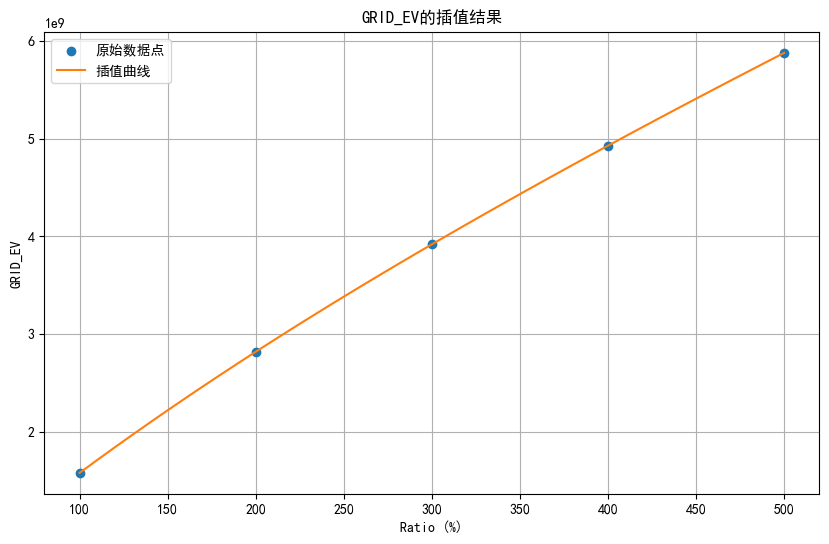

In [10]:
import pandas as pd
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 1. 读取Excel文件
file_path = r'C:\\Users\A\Desktop\\论文图\\敏感性分析\SOC与EV总量\\插值法2.xlsx'
df = pd.read_excel(file_path, index_col=0)    # 第一列作为索引

# 2. 提取原始比率数据（处理列名可能不是字符串的情况）
# 方法1：如果列名已经是数值（如0.00, 0.05, 0.10等）
if all(isinstance(col, (int, float)) for col in df.columns):
    original_ratios = np.array(df.columns)
# 方法2：如果列名是字符串（如"0%", "5%"等）
elif all('%' in str(col) for col in df.columns):
    original_ratios = np.array([float(str(col).replace('%', '')) / 100 for col in df.columns])
else:
    # 如果列名格式不符合预期，尝试强制转换
    try:
        original_ratios = np.array([float(str(col).replace('%', '')) / 100 for col in df.columns])
    except:
        raise ValueError("无法解析列名中的比率值，请检查Excel文件格式")

# 3. 定义插值函数
def interpolate_data(row, new_ratios):
    """对一行数据进行插值"""
    # 获取原始数据点
    x = original_ratios
    y = row.values
    
    # 创建插值函数（这里使用三次样条插值）
    f = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    
    # 计算新比率下的值
    interpolated_values = f(new_ratios)
    
    return interpolated_values

# 4. 插值的比率（例如每1%一个点）
new_ratios = np.arange(1.0, 5.1, 0.1)  # 从0%到20%，步长0.5%

# 5. 对每行数据进行插值
interpolated_data = df.apply(lambda row: interpolate_data(row, new_ratios), axis=1, result_type='expand')

# 6. 创建新的DataFrame
new_columns = [f"{int(r*100)}%" for r in new_ratios]
interpolated_df = pd.DataFrame(interpolated_data.values, index=df.index, columns=new_columns)

# 7. 保存结果到新Excel文件
output_path = r'C:\\Users\A\Desktop\\论文图\\敏感性分析\SOC与EV总量\\插值法_结果2.xlsx'
interpolated_df.to_excel(output_path)

print(f"插值完成，结果已保存到: {output_path}")

# 8. 可选：可视化某个指标的插值结果（例如第一个指标）
if not df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(original_ratios*100, df.iloc[0].values, 'o', label='原始数据点')
    plt.plot(new_ratios*100, interpolated_df.iloc[0].values, '-', label='插值曲线')
    plt.xlabel('Ratio (%)')
    plt.ylabel(df.index[0])
    plt.title(f"{df.index[0]}的插值结果")
    plt.legend()
    plt.grid(True)
    plt.show()

In [1]:
import pandas as pd
import geopandas as gpd

# 读取交通小区人数shapefile
input_shp = "E:\\Electric Ride-Hailing Vehicle\\交通小区中各信令网格人数\\交通小区人数.shp"
gdf = gpd.read_file(input_shp)

# 确保数据包含必要的列
required_columns = ['area_ID', 'density']
if not all(col in gdf.columns for col in required_columns):
    raise ValueError("输入文件缺少必要的列，请确保包含area_ID和density列")

# 根据密度分类
gdf['urban_rural'] = gdf['density'].apply(lambda x: '城区' if x >= 1500 else '郊区')

# 创建结果DataFrame
result_df = gdf[['area_ID', 'density', 'urban_rural']]

# 保存为CSV文件
output_csv = "E:\\Electric Ride-Hailing Vehicle\\交通小区中各信令网格人数\\交通小区城乡分类.csv"
result_df.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f"分类结果已保存到: {output_csv}")

分类结果已保存到: E:\Electric Ride-Hailing Vehicle\交通小区中各信令网格人数\交通小区城乡分类.csv
